# Funky heatmaps for benchmark / multi-metric tables

`ov.pl.funky_heatmap` wraps the
[pyfunkyheatmap](https://github.com/omicverse/py-funkyheatmap) package — a
pure-Python port of the R
[funkyheatmap](https://funkyheatmap.github.io/funkyheatmap/) package. It
produces dynbenchmark-style figures from a `pandas.DataFrame`, with no R /
rpy2 dependency.

This tutorial is organised in four parts:

1. **Quick start** — six worked examples on `mtcars` and small synthetic
   benchmarks covering every glyph type.
2. **Full mtcars walkthrough** — 1:1 port of the R [Getting
   started](https://funkyheatmap.github.io/funkyheatmap/articles/funkyheatmap.html)
   vignette, building the figure up step by step.
3. **Recreating the scIB figures** — 1:1 port of the R
   [scIB](https://funkyheatmap.github.io/funkyheatmap/articles/scIB.html)
   vignette, the benchmark figure from Luecken *et al.* (2022).
4. **dynbenchmark** — pointer to the larger figure (51 methods × 159
   metrics) and how to reproduce it.

> Make sure `pyfunkyheatmap` is installed: `pip install pyfunkyheatmap`.

In [1]:
import omicverse as ov
ov.style(font_path='Arial')

import json
import urllib.request
from io import StringIO
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# fixture URLs — same files used by the upstream pyfunkyheatmap repo
_RAW = 'https://raw.githubusercontent.com/omicverse/py-funkyheatmap/main/data/vignettes'

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Part 1 · Quick start

### 1.1 Default heatmap from a `DataFrame`

The simplest call: pass any `DataFrame` with an `id` column. Numerical
columns become rounded "funky rectangle" glyphs; text columns become
labels.

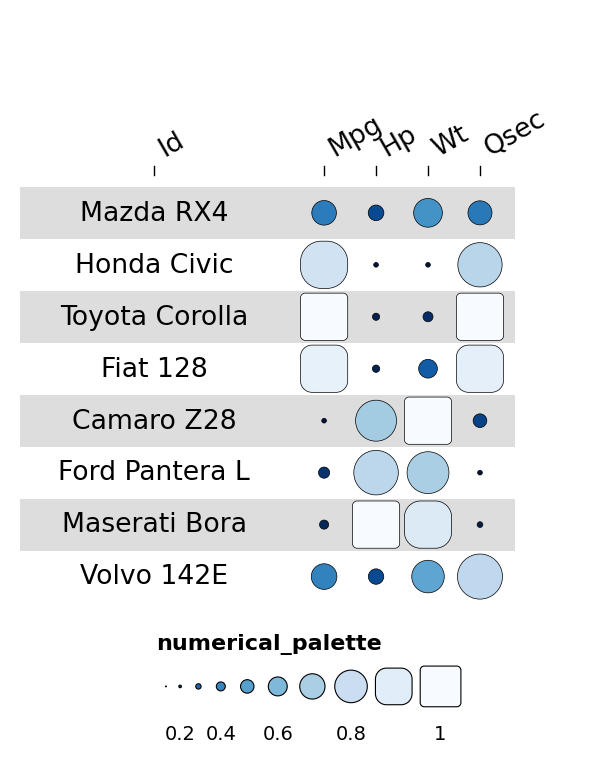

In [2]:
mtcars_small = pd.DataFrame({
    'id':   ['Mazda RX4','Honda Civic','Toyota Corolla','Fiat 128',
             'Camaro Z28','Ford Pantera L','Maserati Bora','Volvo 142E'],
    'mpg':  [21.0, 30.4, 33.9, 32.4, 13.3, 15.8, 15.0, 21.4],
    'hp':   [110, 52, 65, 66, 245, 264, 335, 109],
    'wt':   [2.620, 1.615, 1.835, 2.200, 3.840, 3.170, 3.570, 2.780],
    'qsec': [16.46, 18.52, 19.90, 19.47, 15.41, 14.50, 14.60, 18.60],
})
fh = ov.pl.funky_heatmap(mtcars_small)
fh

### 1.2 Mixing geoms via `column_info`

`column_info` chooses a different geom per column. The valid set is
``funkyrect``, ``circle``, ``rect``, ``bar``, ``pie``, ``text`` and
``image``.

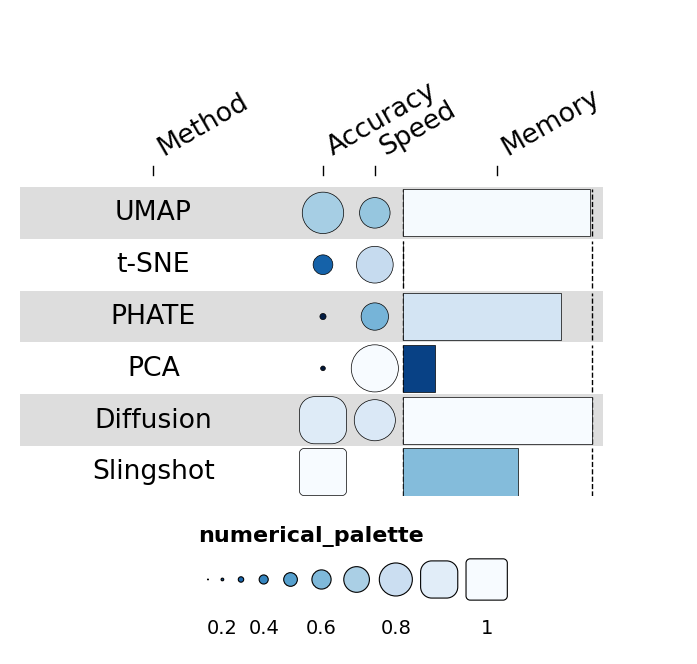

In [3]:
rng = np.random.default_rng(0)
n = 6
benchmark = pd.DataFrame({
    'id':       [f'method_{i}' for i in range(n)],
    'name':     ['UMAP','t-SNE','PHATE','PCA','Diffusion','Slingshot'],
    'accuracy': rng.uniform(0.55, 0.97, n),
    'speed':    rng.uniform(0.10, 0.95, n),
    'memory':   rng.uniform(0.20, 0.95, n),
})
column_info = pd.DataFrame({
    'id':   ['name','accuracy','speed','memory'],
    'name': ['Method','Accuracy','Speed','Memory'],
    'geom': ['text','funkyrect','circle','bar'],
})
fh = ov.pl.funky_heatmap(benchmark, column_info=column_info)
fh

### 1.3 Pie geoms for compositional data

If a column contains dicts of categorical proportions, that column
renders as a pie — the geom the dynbenchmark heatmap uses for "method
components" (e.g. uses graphs / uses MST / uses MDS).

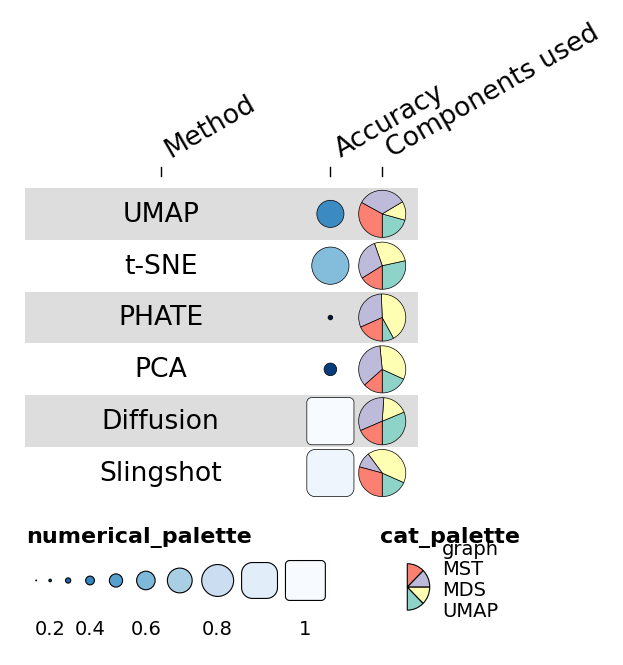

In [4]:
def _comp():
    return {k: float(rng.uniform(0, 1)) for k in ['graph','MST','MDS','UMAP']}

n = 6
df = pd.DataFrame({
    'id':         [f'm{i}' for i in range(n)],
    'name':       ['UMAP','t-SNE','PHATE','PCA','Diffusion','Slingshot'],
    'accuracy':   rng.uniform(0.55, 0.97, n),
    'components': [_comp() for _ in range(n)],
})
column_info = pd.DataFrame({
    'id':      ['name','accuracy','components'],
    'name':    ['Method','Accuracy','Components used'],
    'geom':    ['text','funkyrect','pie'],
    'palette': [None,'numerical_palette','cat_palette'],
})
fh = ov.pl.funky_heatmap(df, column_info=column_info)
fh

### 1.4 Column groups + per-group palettes

For dynbenchmark-style figures, group columns into named categories with
their own palette and a coloured ribbon above the block. The package
draws subfigure letters (`a)`, `b)`, `c)`, …) on the top-level ribbon
automatically.

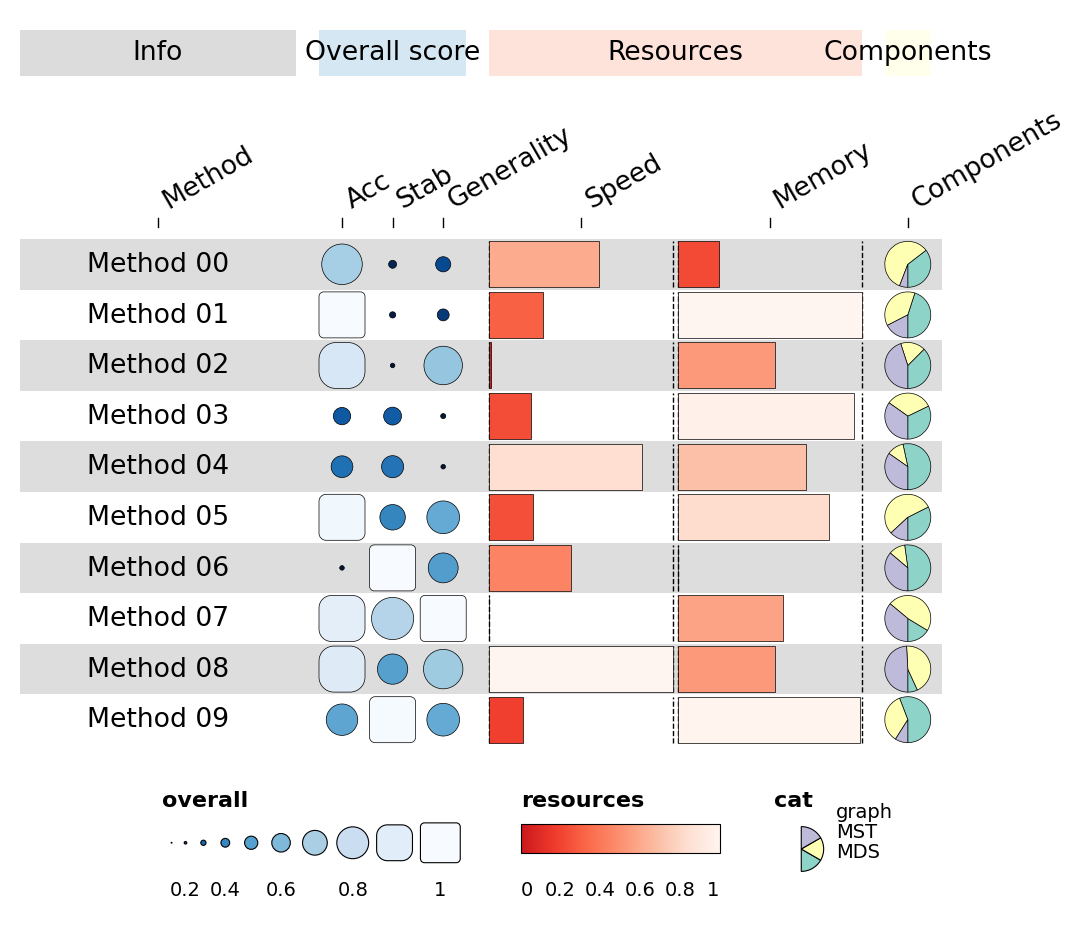

In [5]:
n = 10
rng = np.random.default_rng(7)
df = pd.DataFrame({
    'id':        [f'm{i}' for i in range(n)],
    'name':      [f'Method {i:02d}' for i in range(n)],
    'overall_a': rng.uniform(0.55, 0.97, n),
    'overall_b': rng.uniform(0.40, 0.95, n),
    'overall_c': rng.uniform(0.50, 0.95, n),
    'speed':     rng.uniform(0.10, 0.95, n),
    'memory':    rng.uniform(0.20, 0.95, n),
    'comp':      [{'graph': rng.uniform(0,1), 'MST': rng.uniform(0,1), 'MDS': rng.uniform(0,1)} for _ in range(n)],
})
column_info = pd.DataFrame({
    'id':      ['name','overall_a','overall_b','overall_c','speed','memory','comp'],
    'name':    ['Method','Acc','Stab','Generality','Speed','Memory','Components'],
    'geom':    ['text','funkyrect','funkyrect','funkyrect','bar','bar','pie'],
    'group':   ['info','overall','overall','overall','resources','resources','comp'],
    'palette': [None,'overall','overall','overall','resources','resources','cat'],
})
column_groups = pd.DataFrame({
    'group':   ['info','overall','resources','comp'],
    'level1':  ['Info','Overall score','Resources','Components'],
    'palette': [None,'overall','resources','cat'],
})
fh = ov.pl.funky_heatmap(df, column_info=column_info, column_groups=column_groups)
fh

### 1.5 Custom legends

Pass an explicit `legends` list — each entry is a dict describing one
legend panel. ``geom='rect'`` / ``'funkyrect'`` / ``'circle'`` produces
sized-stop legends; ``'bar'`` produces a continuous gradient.

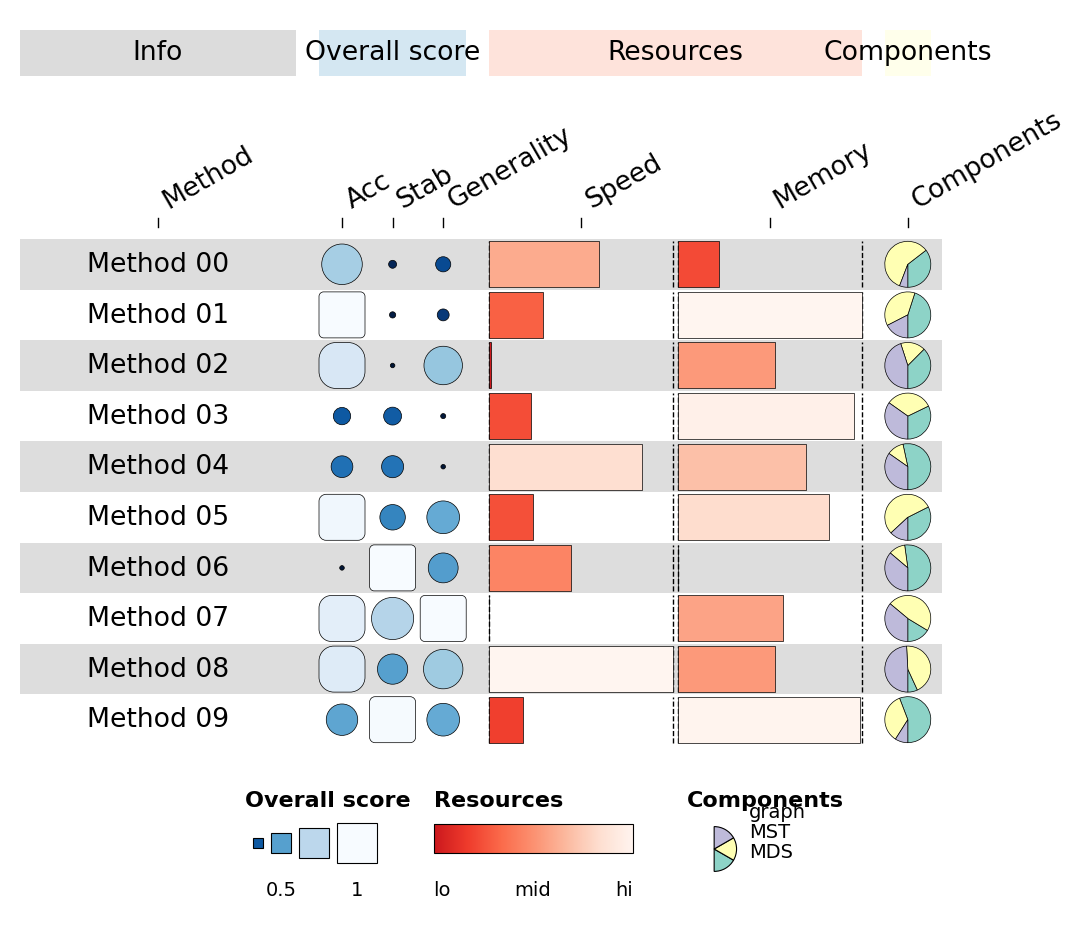

In [6]:
legends = [
    dict(palette='overall',   geom='rect',
         title='Overall score', labels=['0','','0.5','','1']),
    dict(palette='resources', geom='bar',
         title='Resources',     labels=['lo','','mid','','hi']),
    dict(palette='cat',       geom='pie',
         title='Components',    labels=['graph','MST','MDS']),
]
fh = ov.pl.funky_heatmap(df, column_info=column_info,
                          column_groups=column_groups, legends=legends)
fh

### 1.6 Row groups

Highlight a subset of rows by passing `row_info` + `row_groups`. The
heatmap renders each group as its own banded block with a labelled
separator.

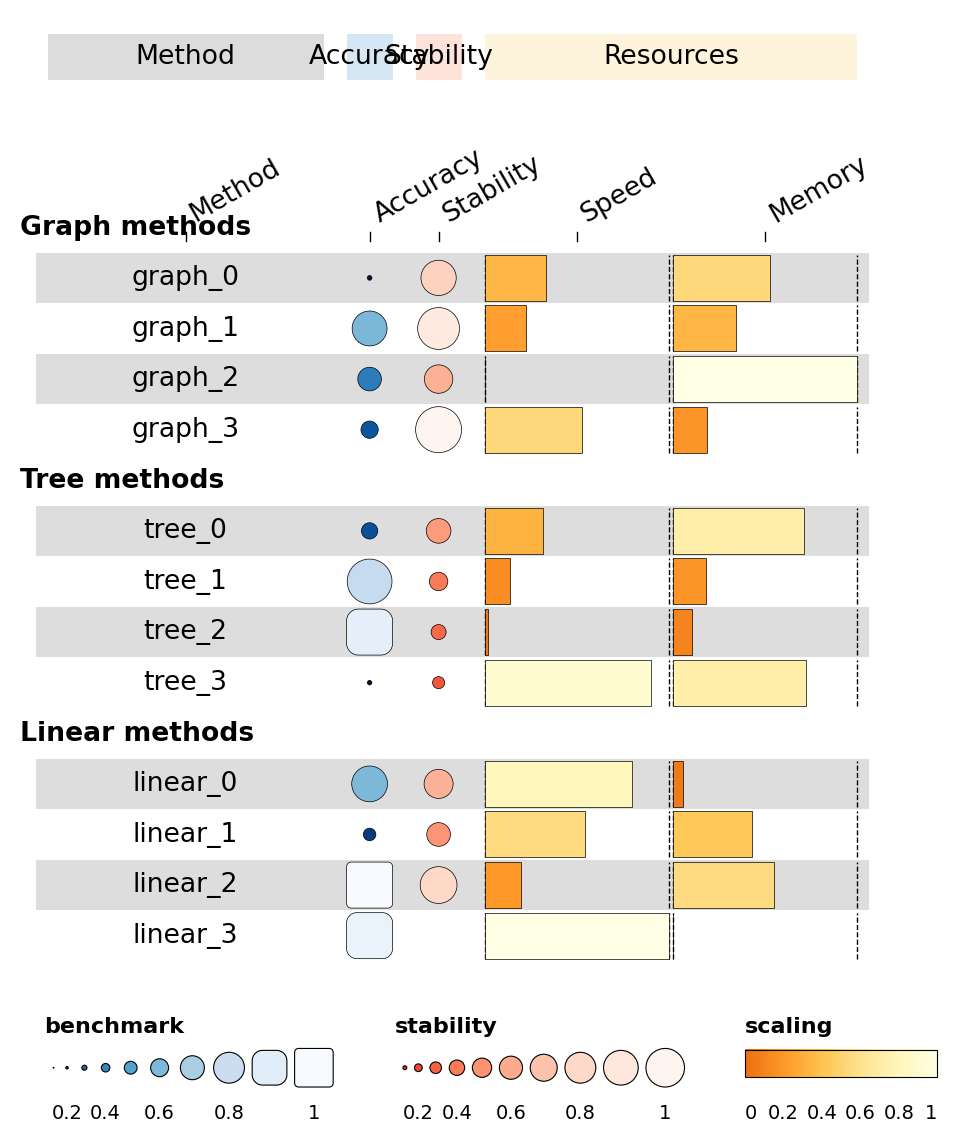

In [7]:
rng = np.random.default_rng(2026)
methods = (
    [f'graph_{i}' for i in range(4)] +
    [f'tree_{i}'  for i in range(4)] +
    [f'linear_{i}' for i in range(4)]
)
df = pd.DataFrame({
    'id':        methods,
    'name':      methods,
    'accuracy':  rng.uniform(0.4, 0.95, len(methods)),
    'stability': rng.uniform(0.3, 0.9,  len(methods)),
    'speed':     rng.uniform(0.1, 0.95, len(methods)),
    'memory':    rng.uniform(0.2, 0.95, len(methods)),
})
column_info = pd.DataFrame({
    'id':      ['name','accuracy','stability','speed','memory'],
    'name':    ['Method','Accuracy','Stability','Speed','Memory'],
    'geom':    ['text','funkyrect','circle','bar','bar'],
    'group':   ['info','accuracy','stability','resources','resources'],
    'palette': [None,'benchmark','stability','scaling','scaling'],
})
column_groups = pd.DataFrame({
    'group':  ['info','accuracy','stability','resources'],
    'level1': ['Method','Accuracy','Stability','Resources'],
    'palette':[None,'benchmark','stability','scaling'],
})
row_info = pd.DataFrame({
    'id': df['id'],
    'group': ['Graph methods']*4 + ['Tree methods']*4 + ['Linear methods']*4,
})
row_groups = pd.DataFrame({
    'group':  ['Graph methods','Tree methods','Linear methods'],
    'level1': ['Graph methods','Tree methods','Linear methods'],
})
fh = ov.pl.funky_heatmap(
    df, column_info=column_info, column_groups=column_groups,
    row_info=row_info, row_groups=row_groups,
    position_args=ov.pl.funky_position_arguments(col_annot_offset=3.2),
)
fh

## Part 2 · Full mtcars walkthrough

This section is a Python 1:1 port of the R
[Getting started](https://funkyheatmap.github.io/funkyheatmap/articles/funkyheatmap.html)
vignette. We start with a bare `funky_heatmap(data)` call and add
features one at a time.

### 2.1 Loading the data

Load `mtcars`, promote the row names to an `id` column, sort by `mpg`
descending and keep the top 30 rows.

In [8]:
csv = urllib.request.urlopen(f'{_RAW}/mtcars.csv').read().decode()
mtcars = pd.read_csv(StringIO(csv)).rename(columns={'Unnamed: 0':'id'})
data = mtcars.sort_values('mpg', ascending=False).head(30).reset_index(drop=True)
data.head()

,id,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Toyota Corolla,33.9,4,71.1,65,4.22,1.835,19.90,1,1,4,1
1,Fiat 128,32.4,4,78.7,66,4.08,2.200,19.47,1,1,4,1
2,Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.90,1,1,5,2
3,Honda Civic,30.4,4,75.7,52,4.93,1.615,18.52,1,1,4,2
4,Fiat X1-9,27.3,4,79.0,66,4.08,1.935,18.90,1,1,4,1


Plot this `DataFrame` without any additional metadata — it doesn't look great yet:

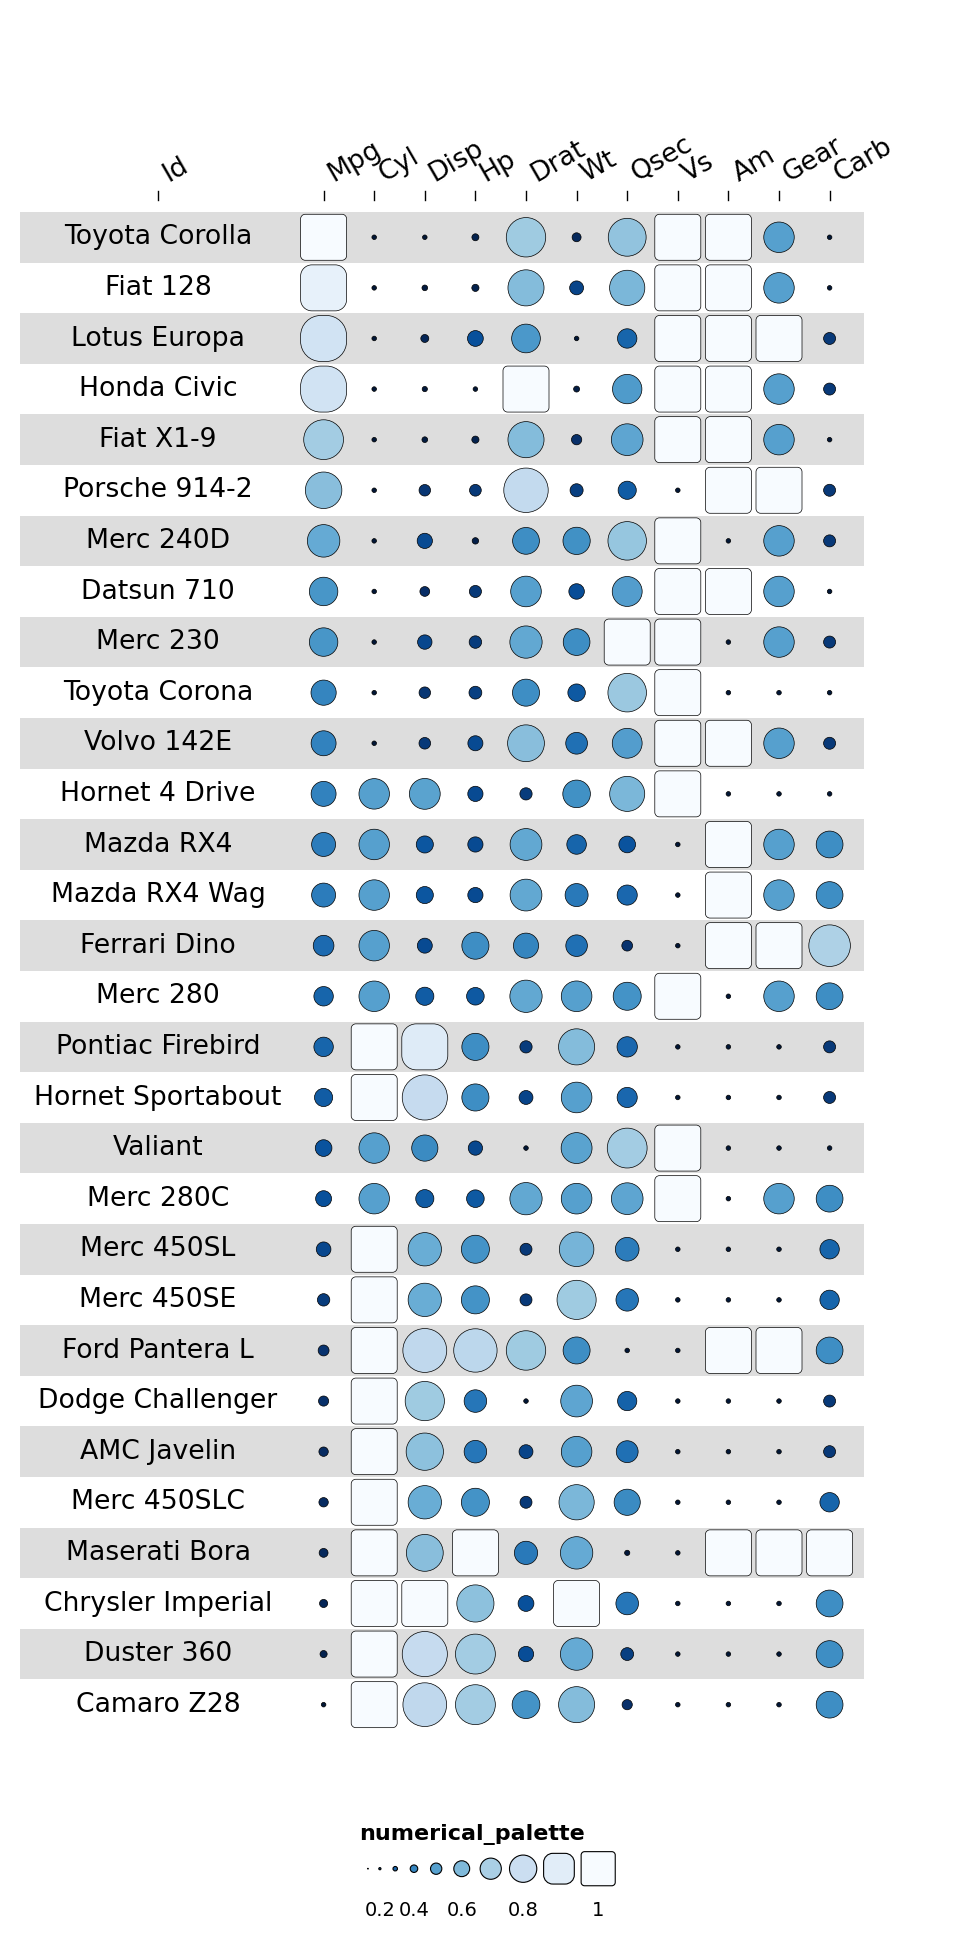

In [9]:
ov.pl.funky_heatmap(data)

### 2.2 Adding `column_info`

`column_info` is a `DataFrame` with one row per heatmap column. The
required column is `id`; everything else is optional.

If you want to group columns together, specify the `group` field.

In [10]:
cinfo = pd.DataFrame({
    'id': data.columns,
    'group': [None, 'Overall', 'Engine', 'Engine', 'Engine', 'Transmission',
              'Overall', 'Performance', 'Engine', 'Transmission',
              'Transmission', 'Engine'],
    'options': ['{}'] * 12,
})
cinfo

,id,group,options
0,id,None,{}
1,mpg,Overall,{}
2,cyl,Engine,{}
3,disp,Engine,{}
4,hp,Engine,{}
5,drat,Transmission,{}
6,wt,Overall,{}
7,qsec,Performance,{}
8,vs,Engine,{}
9,am,Transmission,{}


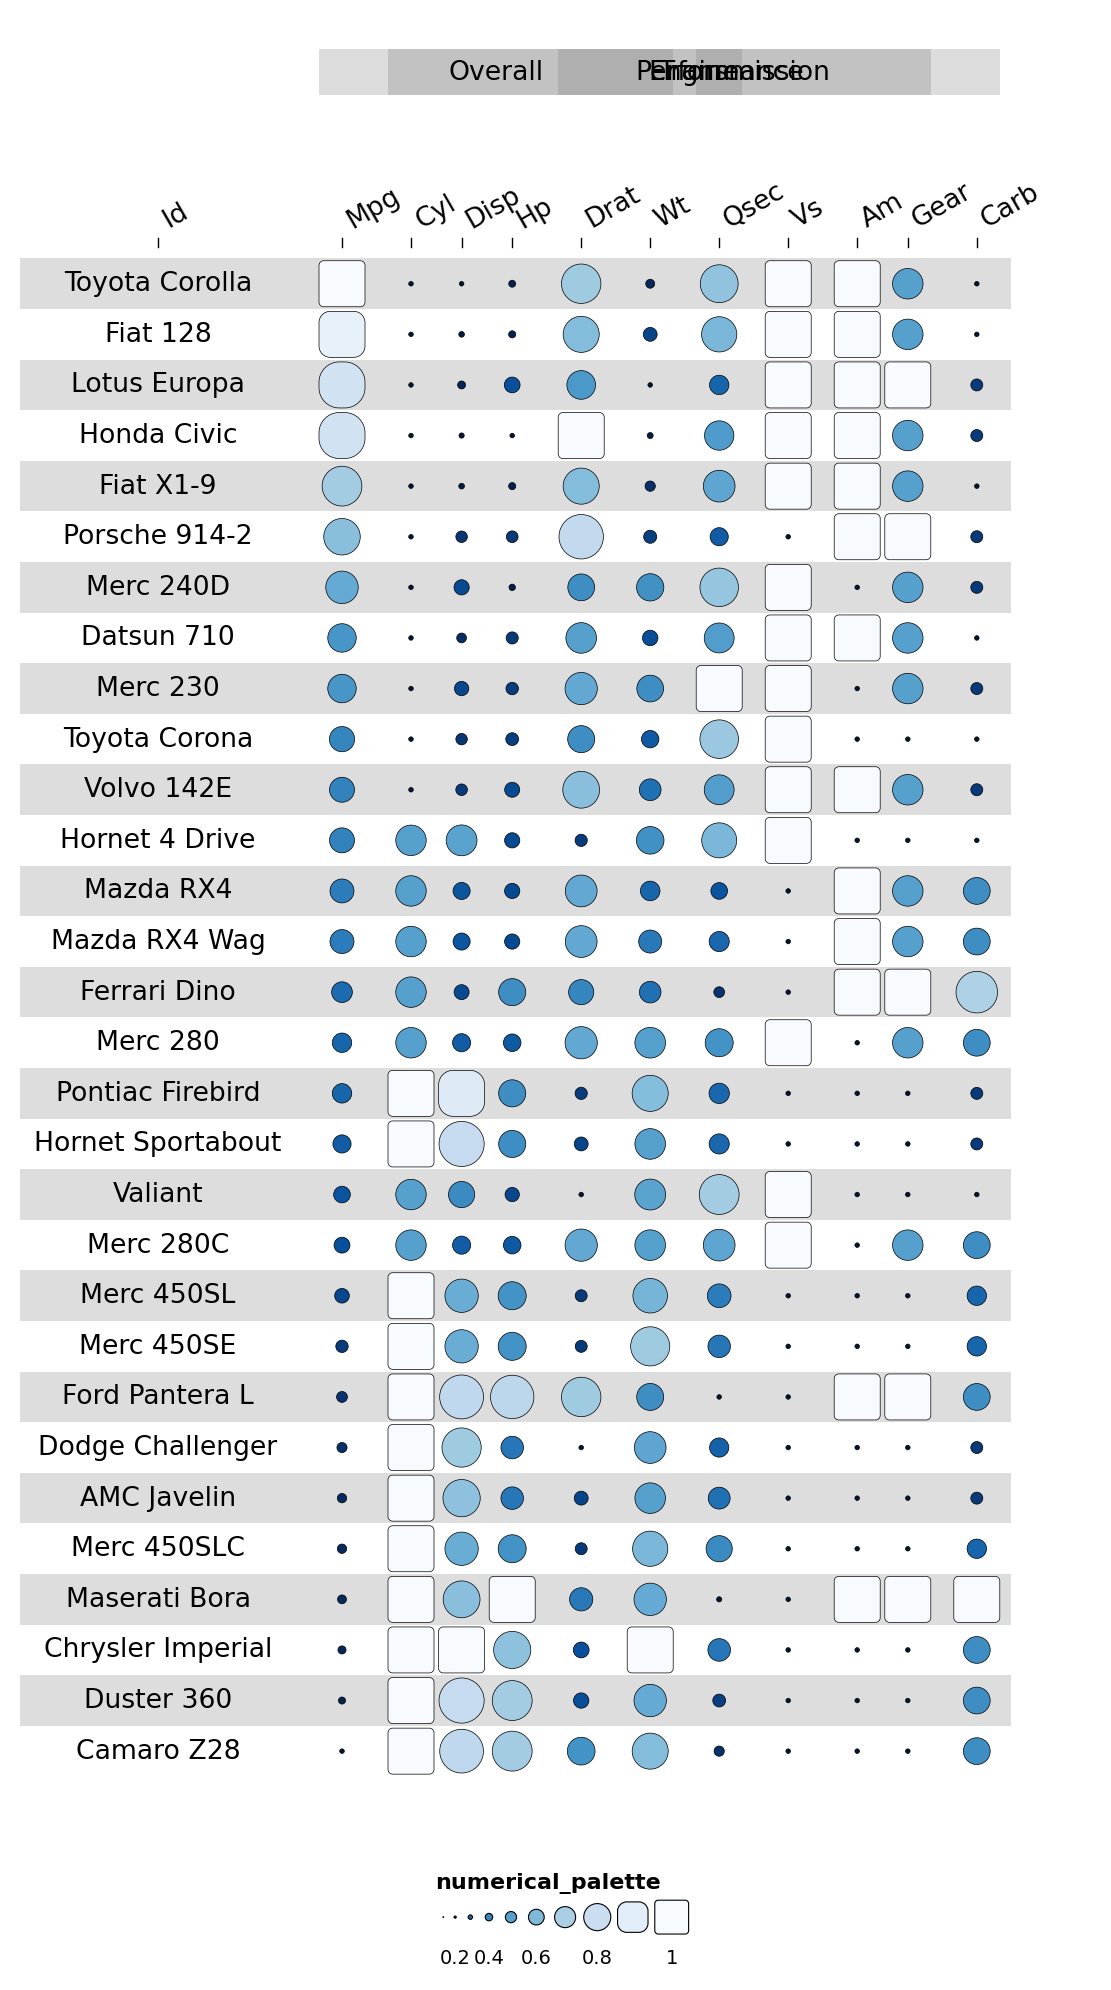

In [11]:
ov.pl.funky_heatmap(data, column_info=cinfo)

This doesn't quite work yet: we need to rearrange the columns so
those in the same group are adjacent.

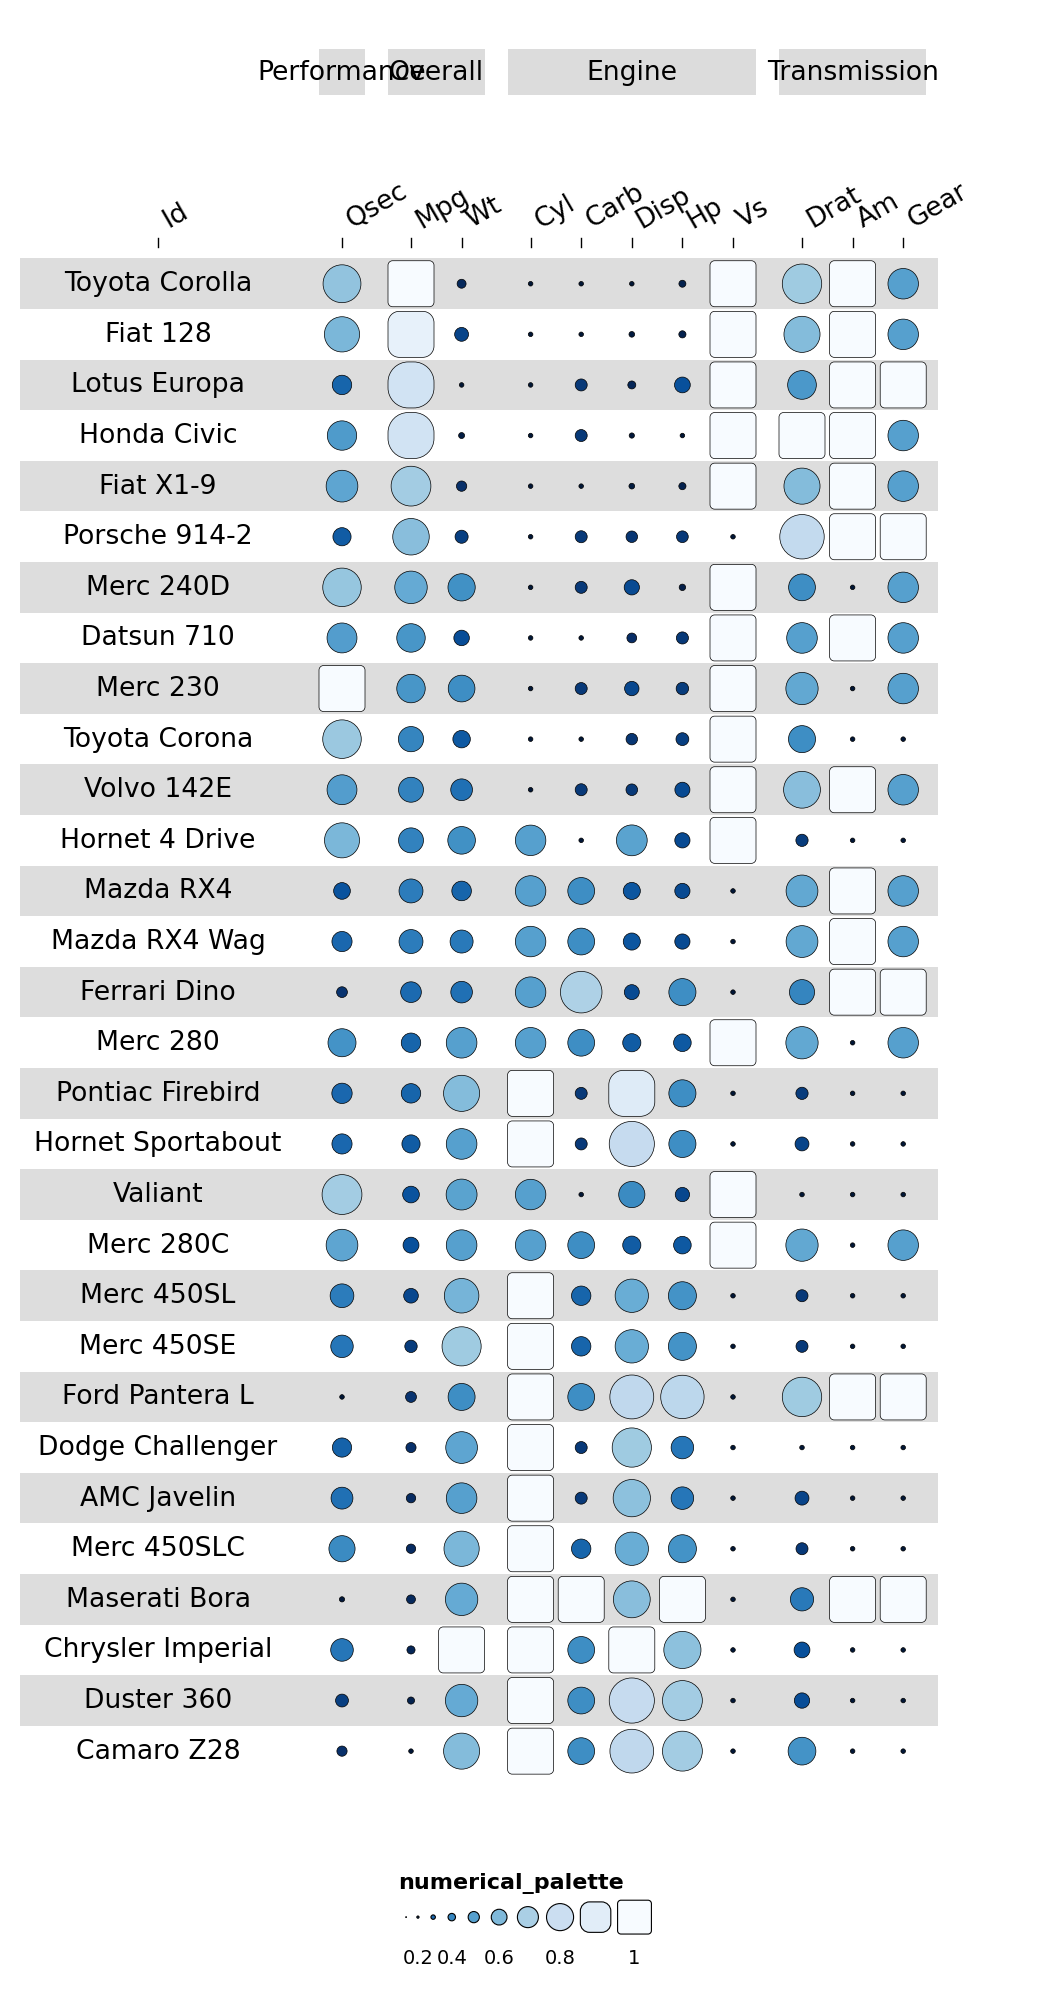

In [12]:
data = data[['id','qsec','mpg','wt','cyl','carb','disp','hp','vs','drat','am','gear']]

cinfo = pd.DataFrame({
    'id': data.columns,
    'group': [None, 'Performance', 'Overall', 'Overall',
              'Engine', 'Engine', 'Engine', 'Engine', 'Engine',
              'Transmission', 'Transmission', 'Transmission'],
    'options': ['{}'] * 12,
})
ov.pl.funky_heatmap(data, column_info=cinfo)

A `name` column gives each column a human-readable header:

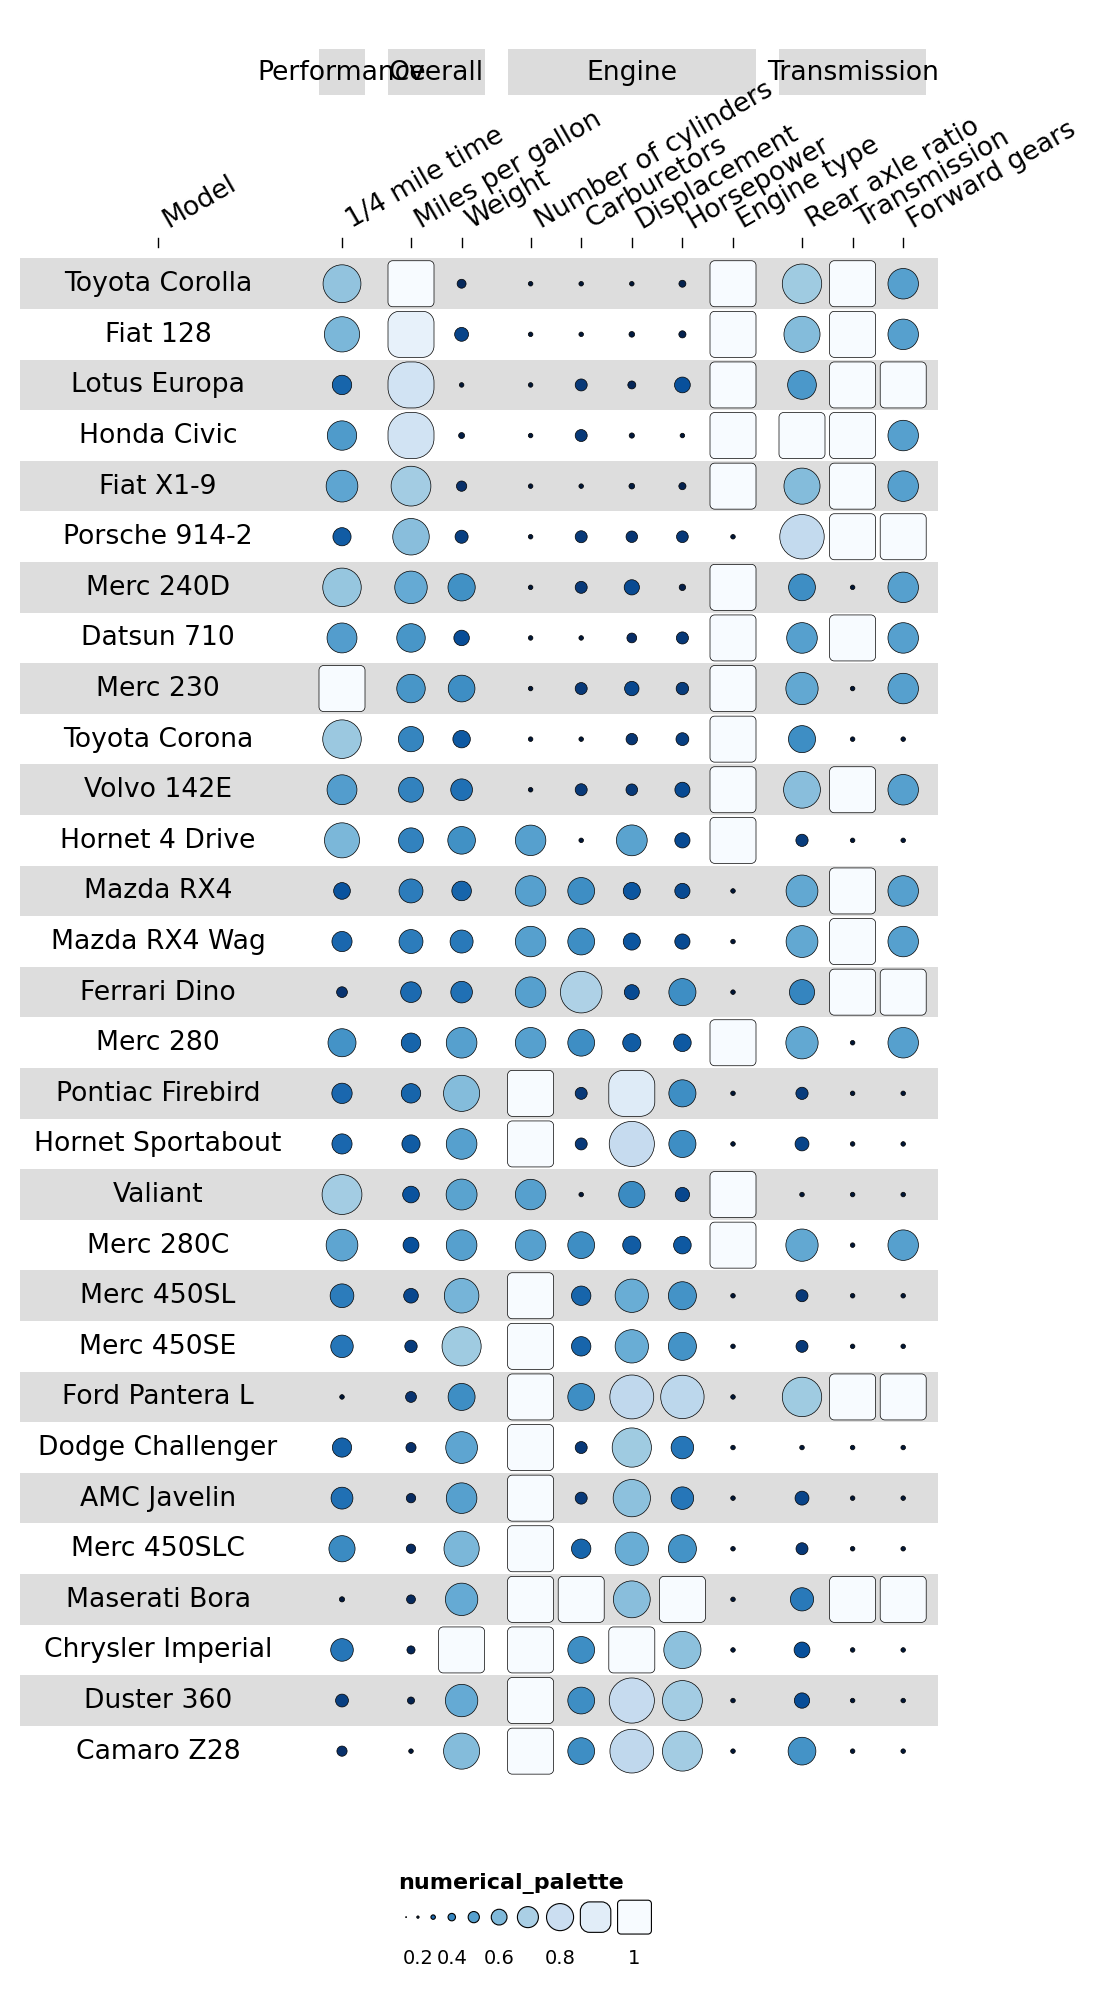

In [13]:
cinfo['name'] = ['Model','1/4 mile time','Miles per gallon','Weight',
                 'Number of cylinders','Carburetors','Displacement','Horsepower',
                 'Engine type','Rear axle ratio','Transmission','Forward gears']
ov.pl.funky_heatmap(data, column_info=cinfo)

### 2.3 Adding palettes

A `palette` column points each data column to a named palette in the
`palettes` dict. Built-in palette names:

- **Numerical:** `Blues`, `Reds`, `Greens`, `YlOrBr`, `Greys`
- **Categorical:** `Set1`, `Set2`, `Set3`, `Dark2`

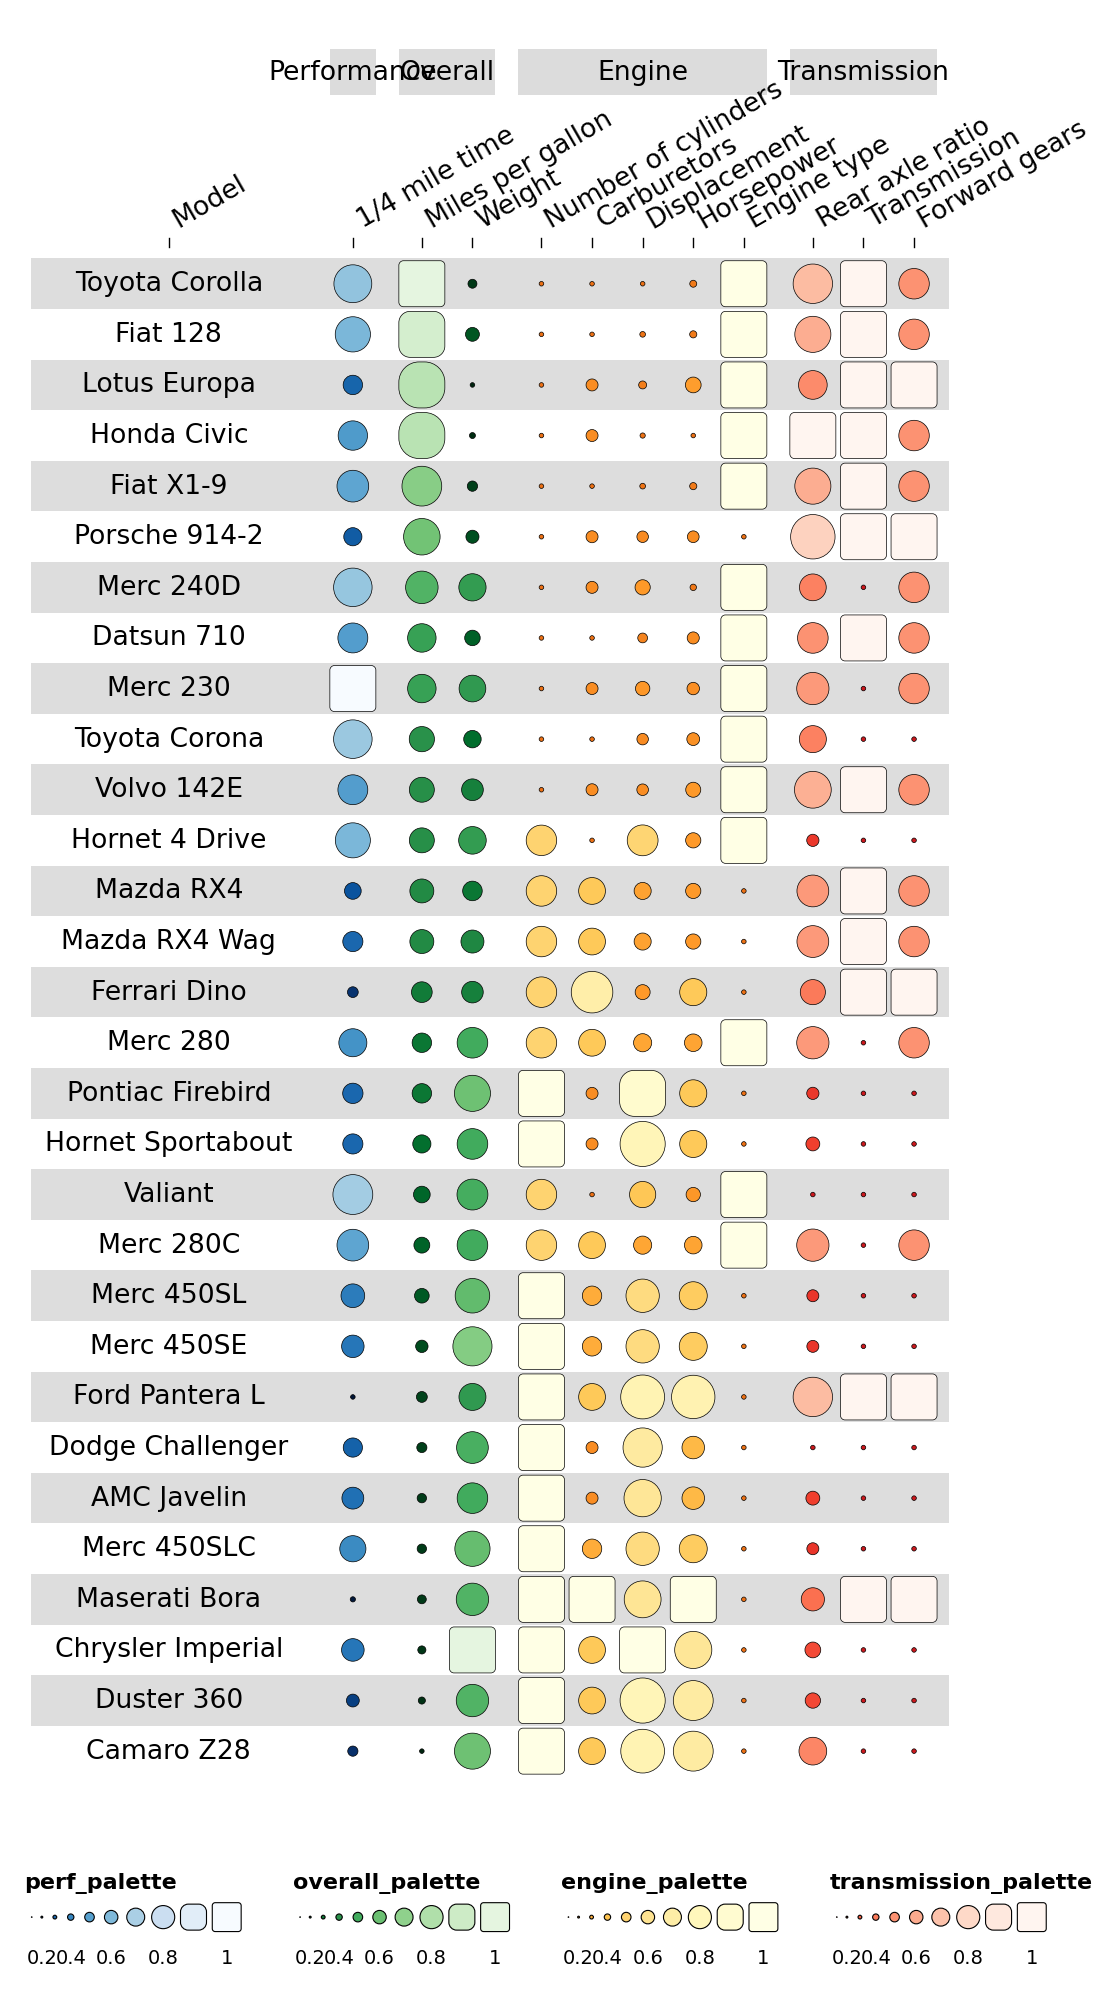

In [14]:
cinfo['palette'] = [None, 'perf_palette',
                    'overall_palette', 'overall_palette',
                    'engine_palette', 'engine_palette', 'engine_palette',
                    'engine_palette', 'engine_palette',
                    'transmission_palette', 'transmission_palette', 'transmission_palette']
palettes = {
    'perf_palette':         'Blues',
    'overall_palette':      'Greens',
    'engine_palette':       'YlOrBr',
    'transmission_palette': 'Reds',
}
ov.pl.funky_heatmap(data, column_info=cinfo, palettes=palettes)

### 2.4 Adding `column_groups`

Colour the column-group ribbons by adding `column_groups`:
- `Category` (or `level1`) — the display name
- `group` — links to `column_info.group`
- `palette` — colour to use for that ribbon

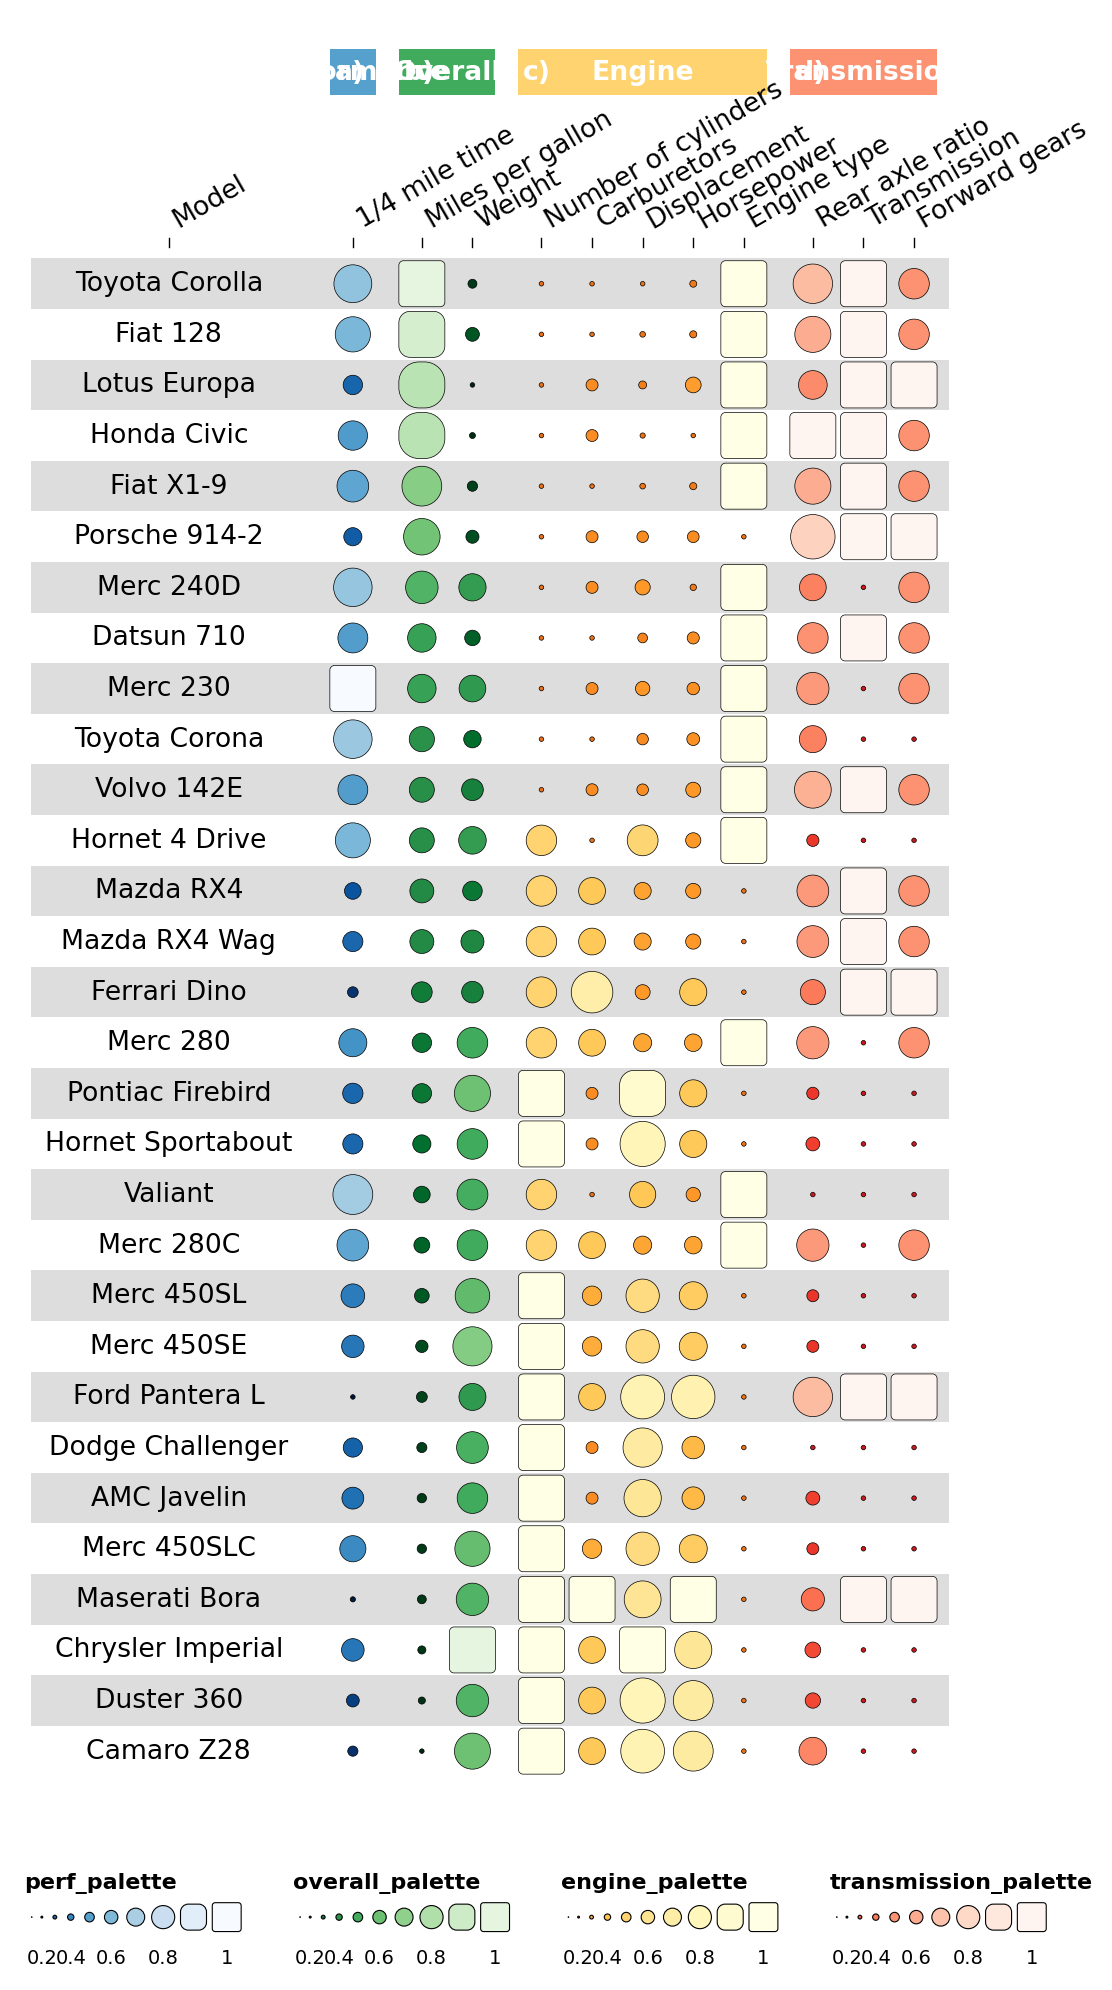

In [15]:
column_groups = pd.DataFrame({
    'Category': ['Performance','Overall','Engine','Transmission'],
    'group':    ['Performance','Overall','Engine','Transmission'],
    'palette':  ['perf_palette','overall_palette','engine_palette','transmission_palette'],
})
ov.pl.funky_heatmap(data, column_info=cinfo, column_groups=column_groups, palettes=palettes)

### 2.5 Specifying geoms

Make some columns display differently. Cylinder & carb counts are
discrete, so render them as `rect`s; horsepower/displacement keep the
funky rectangle.

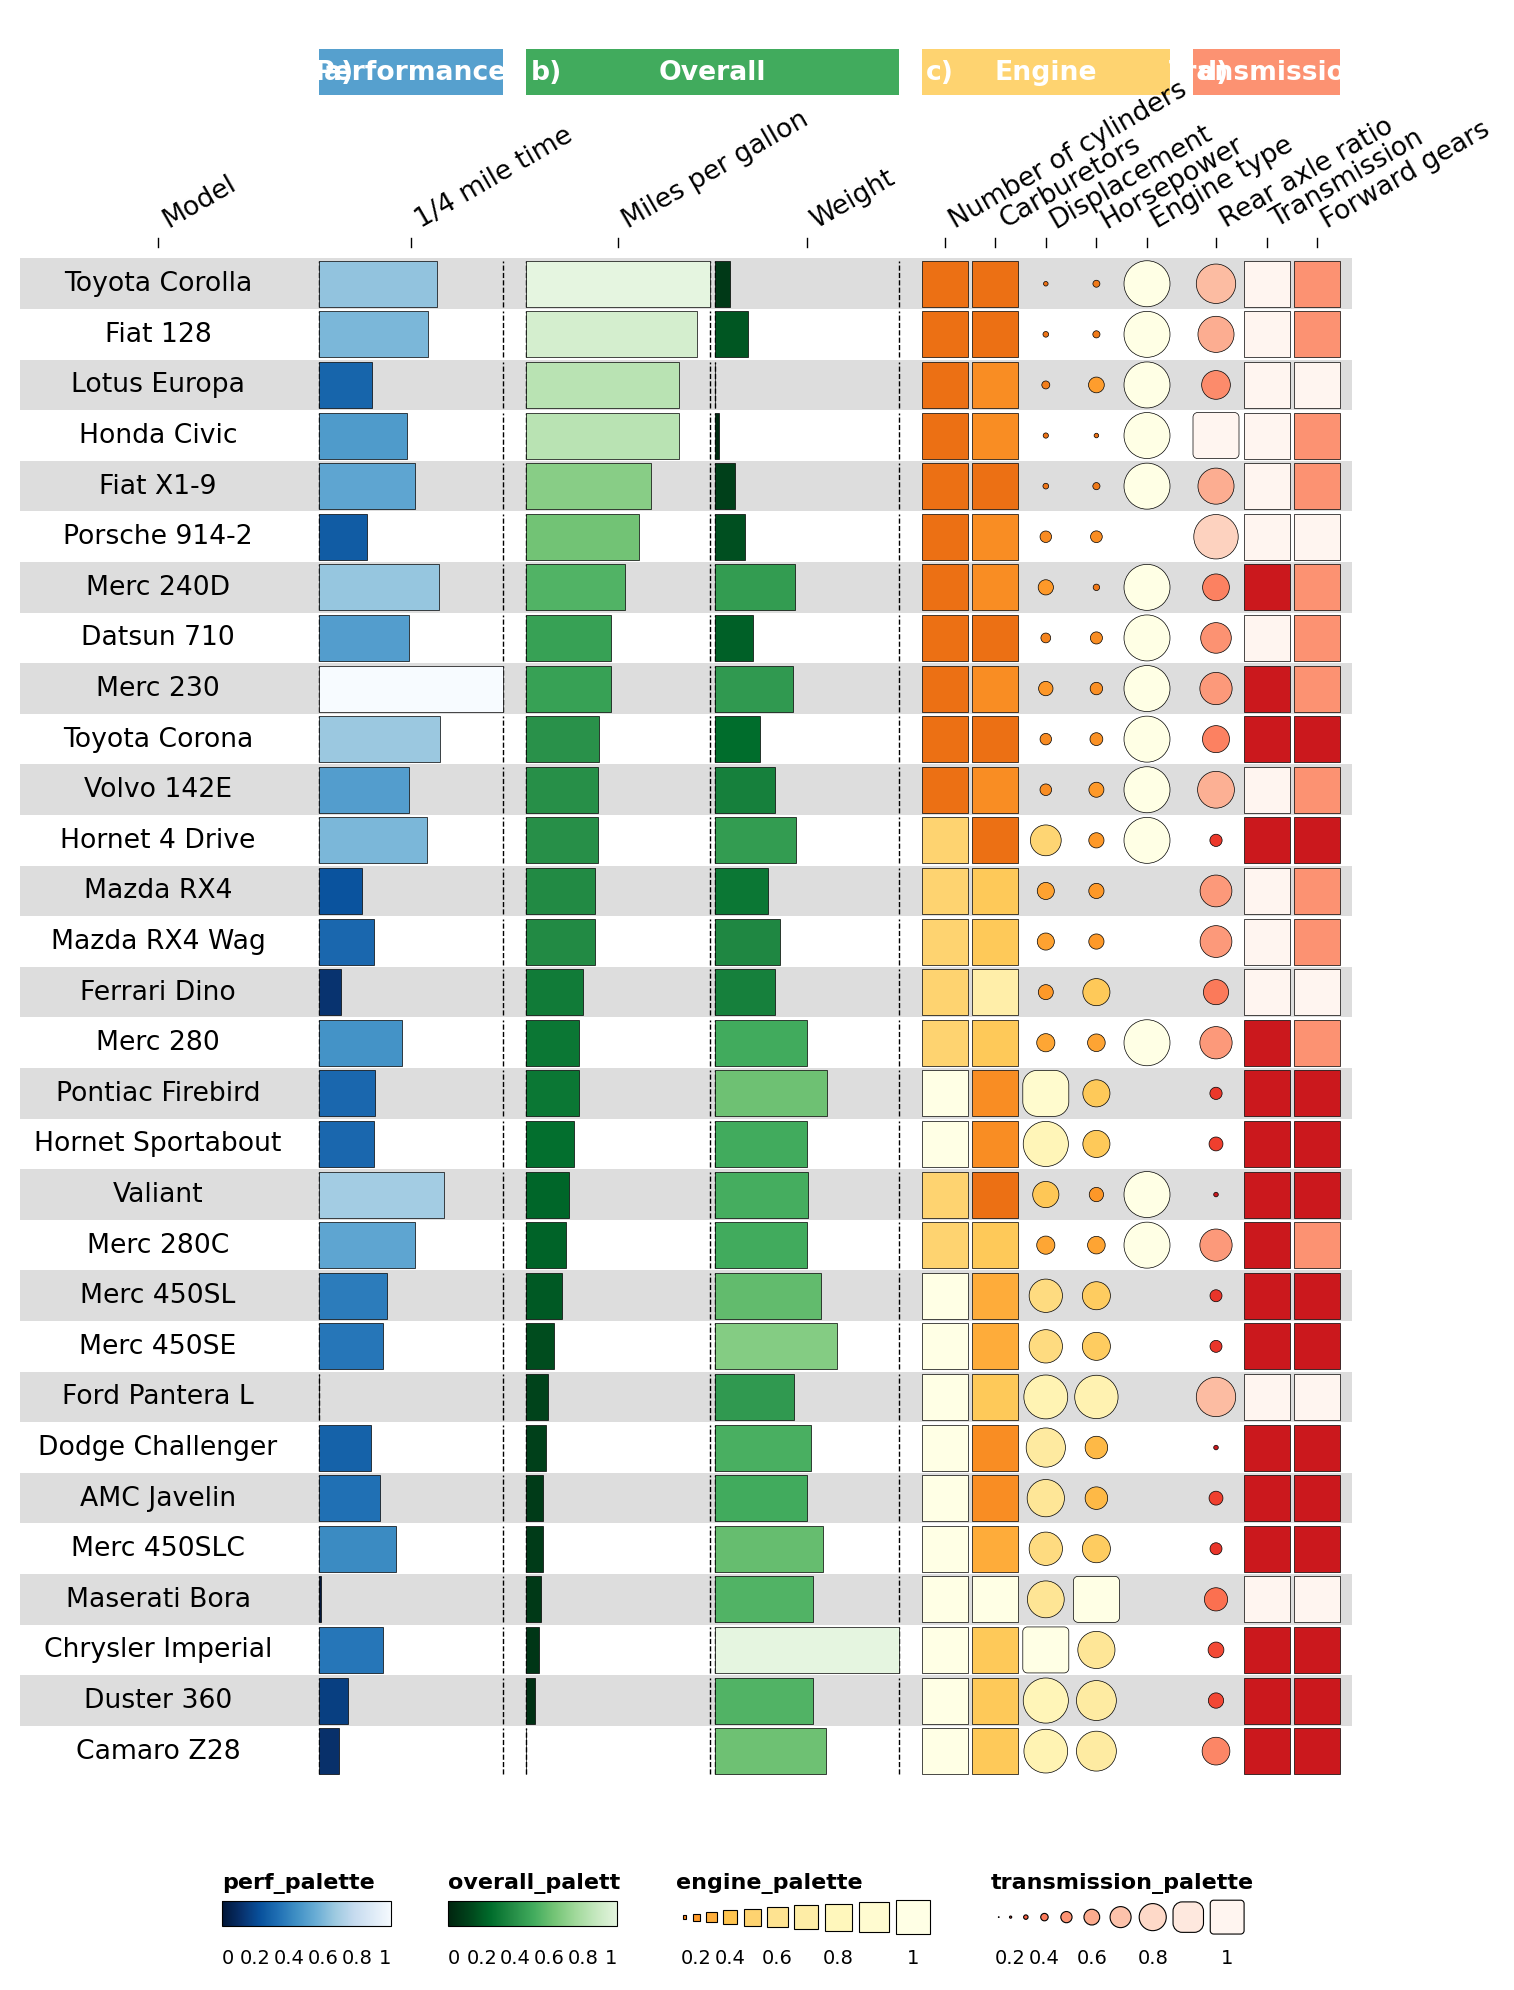

In [16]:
cinfo['geom'] = ['text','bar','bar','bar','rect','rect','funkyrect','funkyrect',
                 'circle','funkyrect','rect','rect']
ov.pl.funky_heatmap(data, column_info=cinfo, column_groups=column_groups, palettes=palettes)

Overlay text labels on the discrete rectangle cells:

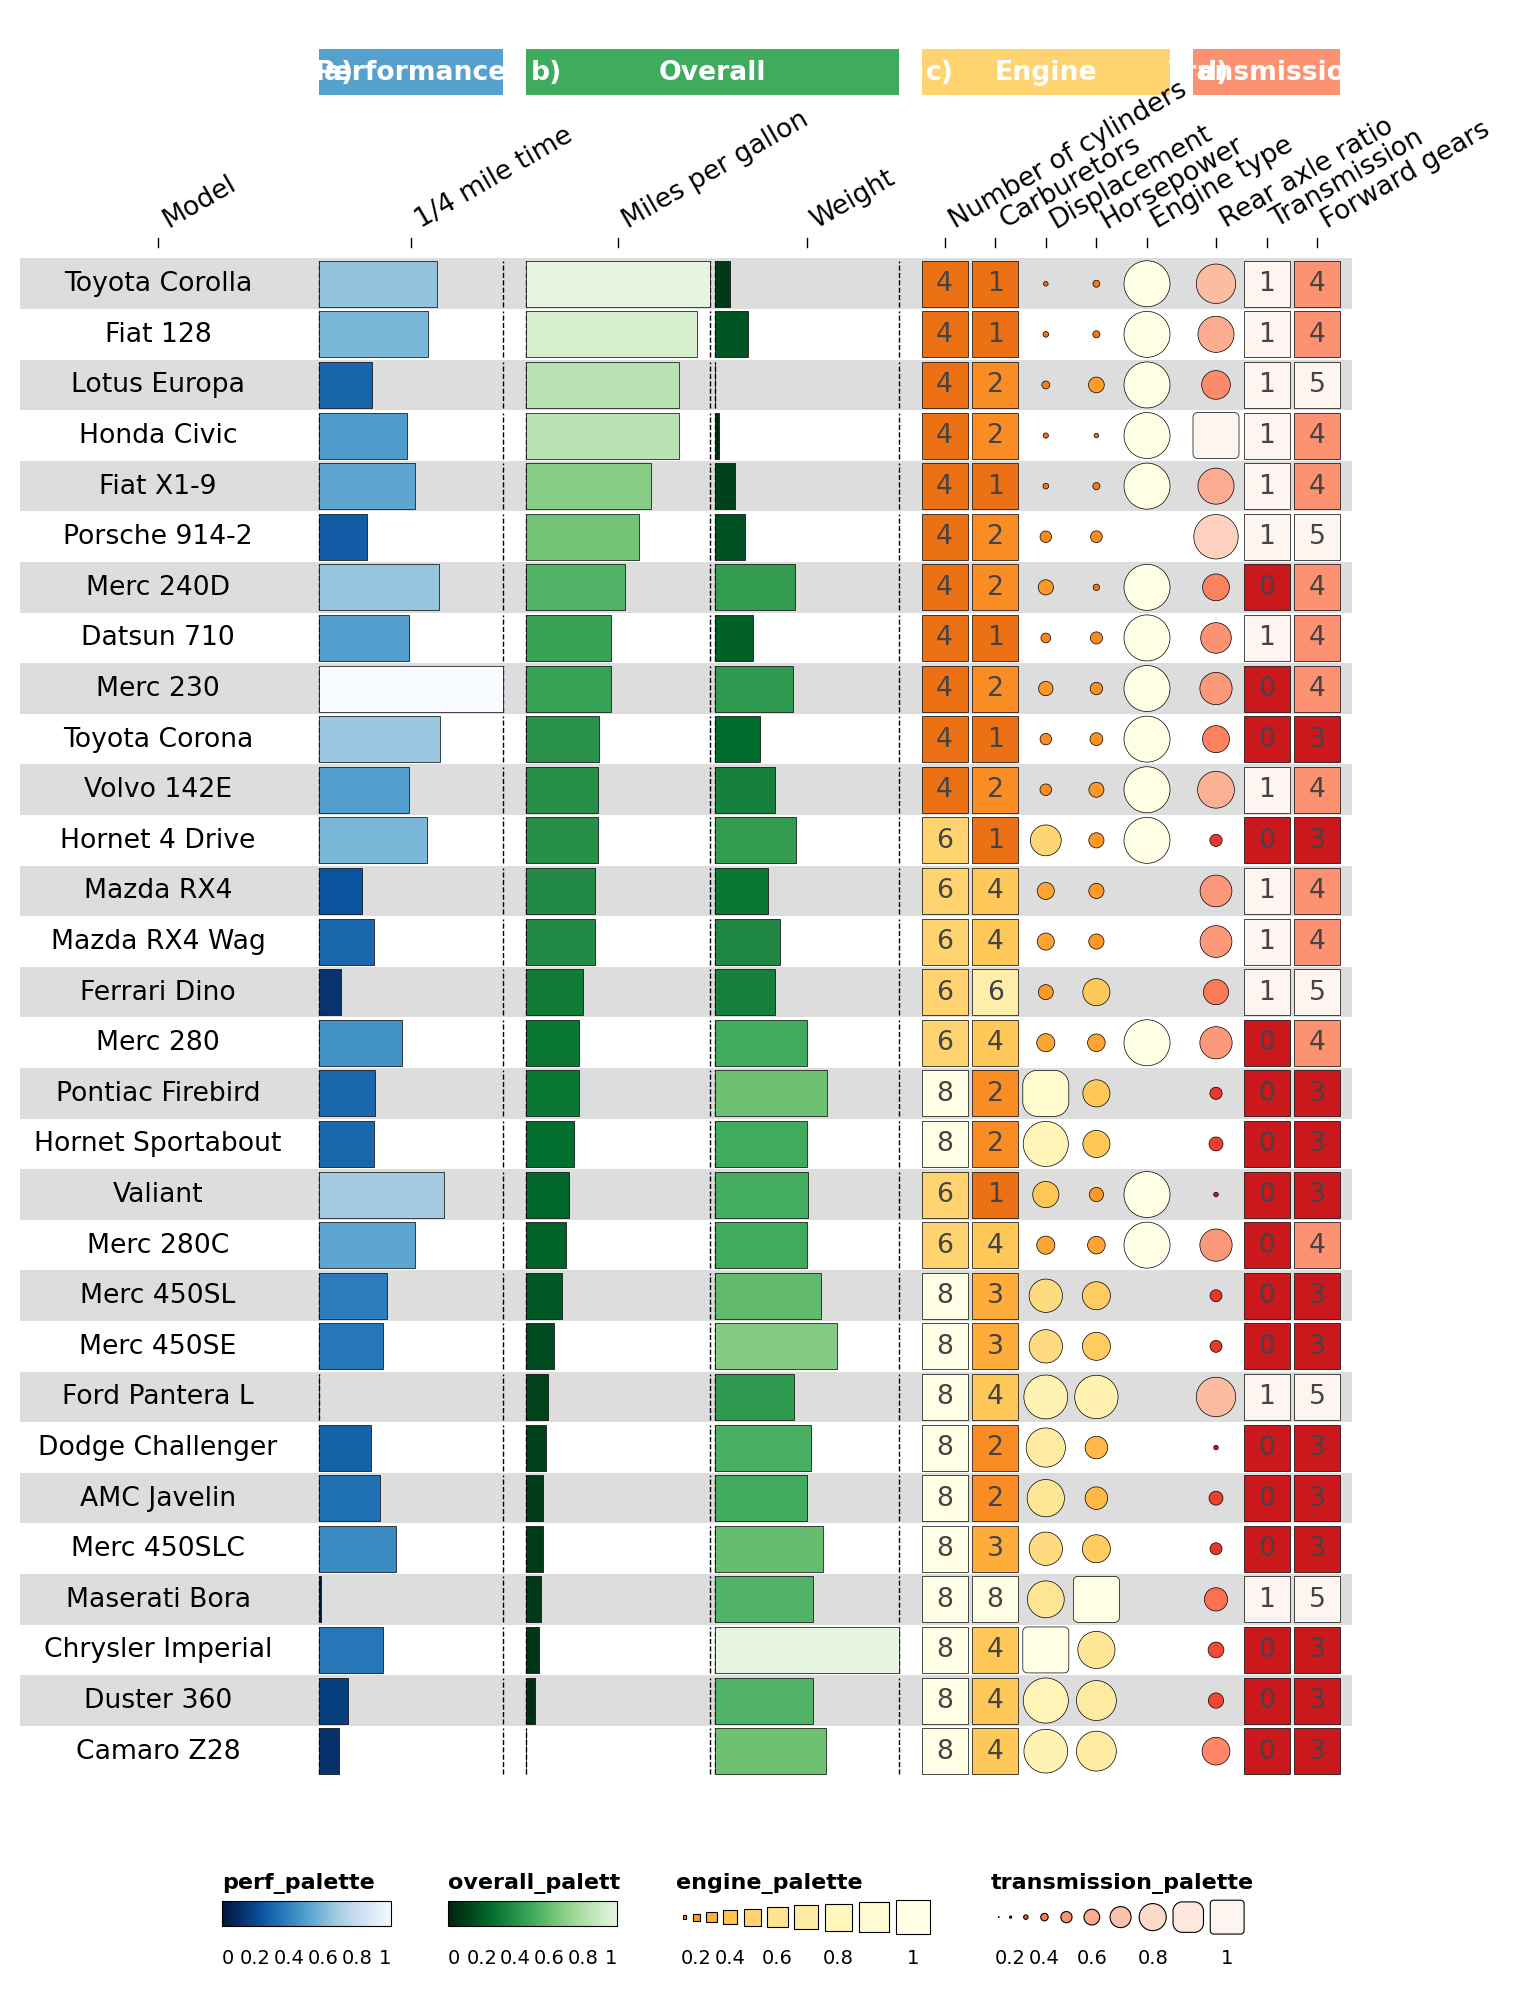

In [17]:
def insert_overlay_at(df, *, before_iloc1, new_id, group, palette='black'):
    """Mirror R's `add_row(.before=N)` — insert at 1-indexed position."""
    pos = before_iloc1 - 1
    if pos >= len(df):
        pos = len(df)
    row = {
        'id': new_id, 'group': group, 'name': '', 'geom': 'text',
        'options': json.dumps({'overlay': True}), 'palette': palette,
    }
    return pd.concat([df.iloc[:pos], pd.DataFrame([row]), df.iloc[pos:]],
                     ignore_index=True)

cinfo = insert_overlay_at(cinfo, before_iloc1=6,  new_id='cyl',  group='Engine')
cinfo = insert_overlay_at(cinfo, before_iloc1=8,  new_id='carb', group='Engine')
cinfo = insert_overlay_at(cinfo, before_iloc1=14, new_id='am',   group='Transmission')
cinfo = insert_overlay_at(cinfo, before_iloc1=17, new_id='gear', group='Transmission')
palettes['black'] = ['black', 'black']

ov.pl.funky_heatmap(data, column_info=cinfo, column_groups=column_groups, palettes=palettes)

### 2.6 Customising legends

Each `legends` entry describes a legend panel. We can give multiple
legends for the same palette by adding multiple entries.

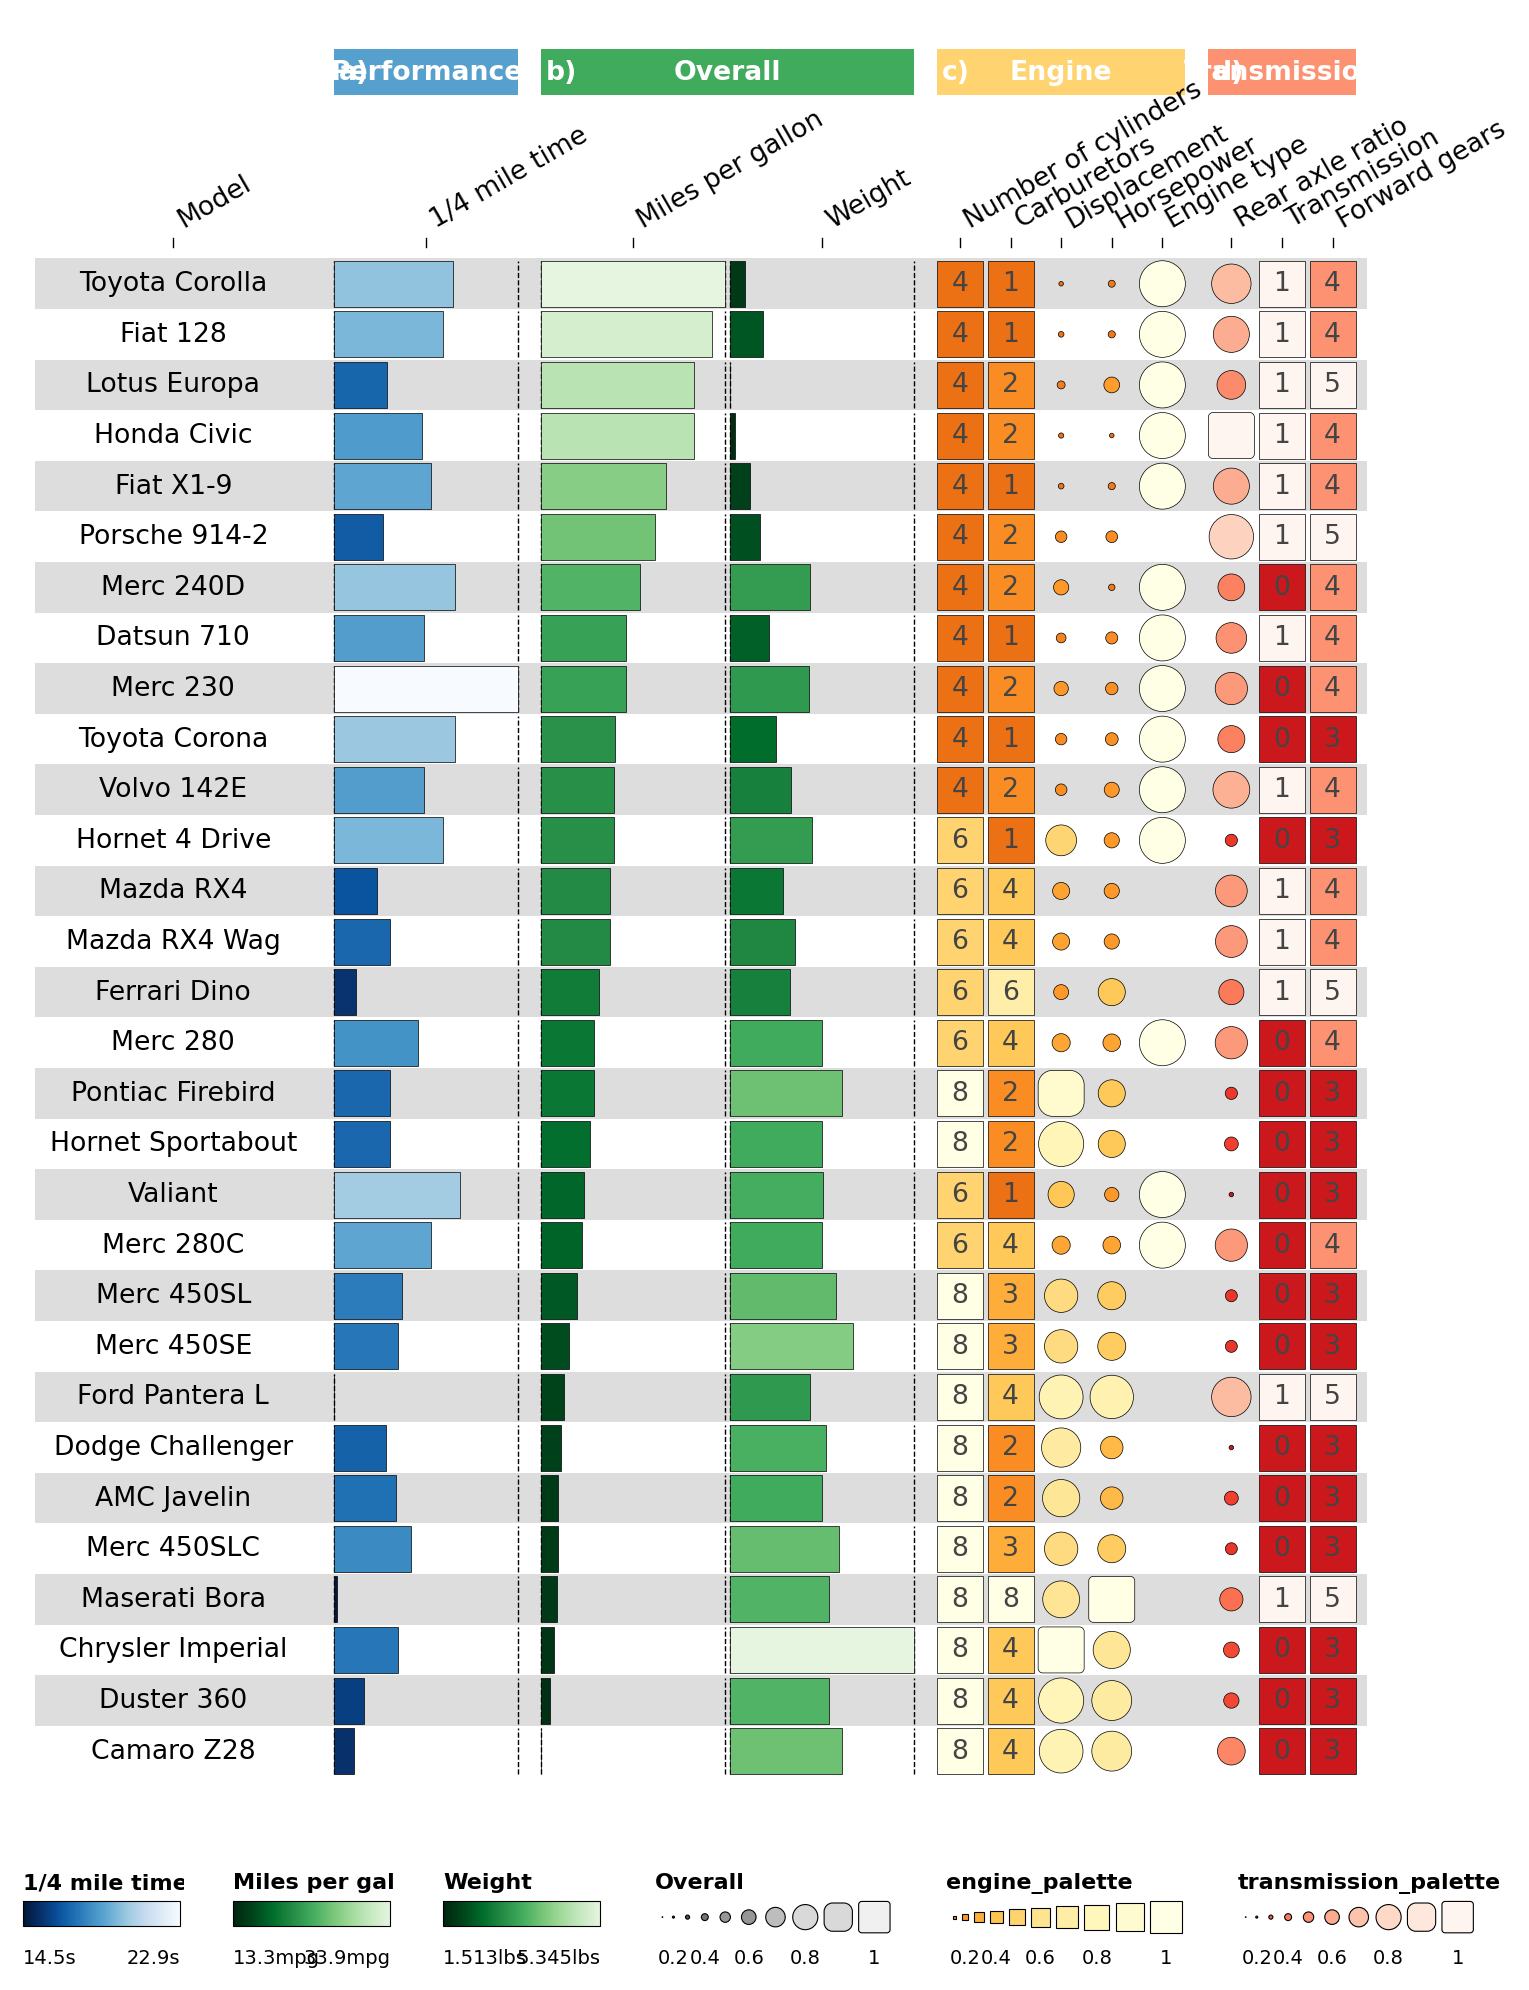

In [18]:
greys9_rev = list(reversed(['#FFFFFF','#F0F0F0','#D9D9D9','#BDBDBD','#969696',
                            '#737373','#525252','#252525','#000000']))[:-1]
palettes['funky_palette_grey'] = greys9_rev

legends = [
    dict(palette='perf_palette',    geom='bar', title='1/4 mile time',
         labels=[f"{data['qsec'].min()}s"] + [''] * 8 + [f"{data['qsec'].max()}s"]),
    dict(palette='overall_palette', geom='bar', title='Miles per gallon',
         labels=[f"{data['mpg'].min()}mpg"] + [''] * 8 + [f"{data['mpg'].max()}mpg"]),
    dict(palette='overall_palette', geom='bar', title='Weight',
         labels=[f"{data['wt'].min()}lbs"]  + [''] * 8 + [f"{data['wt'].max()}lbs"]),
    dict(palette='funky_palette_grey', geom='funkyrect', title='Overall', enabled=True,
         labels=['0','','0.2','','0.4','','0.6','','0.8','','1']),
]
ov.pl.funky_heatmap(data, column_info=cinfo, column_groups=column_groups,
                    palettes=palettes, legends=legends)

Disable redundant palette legends with `enabled=False`:

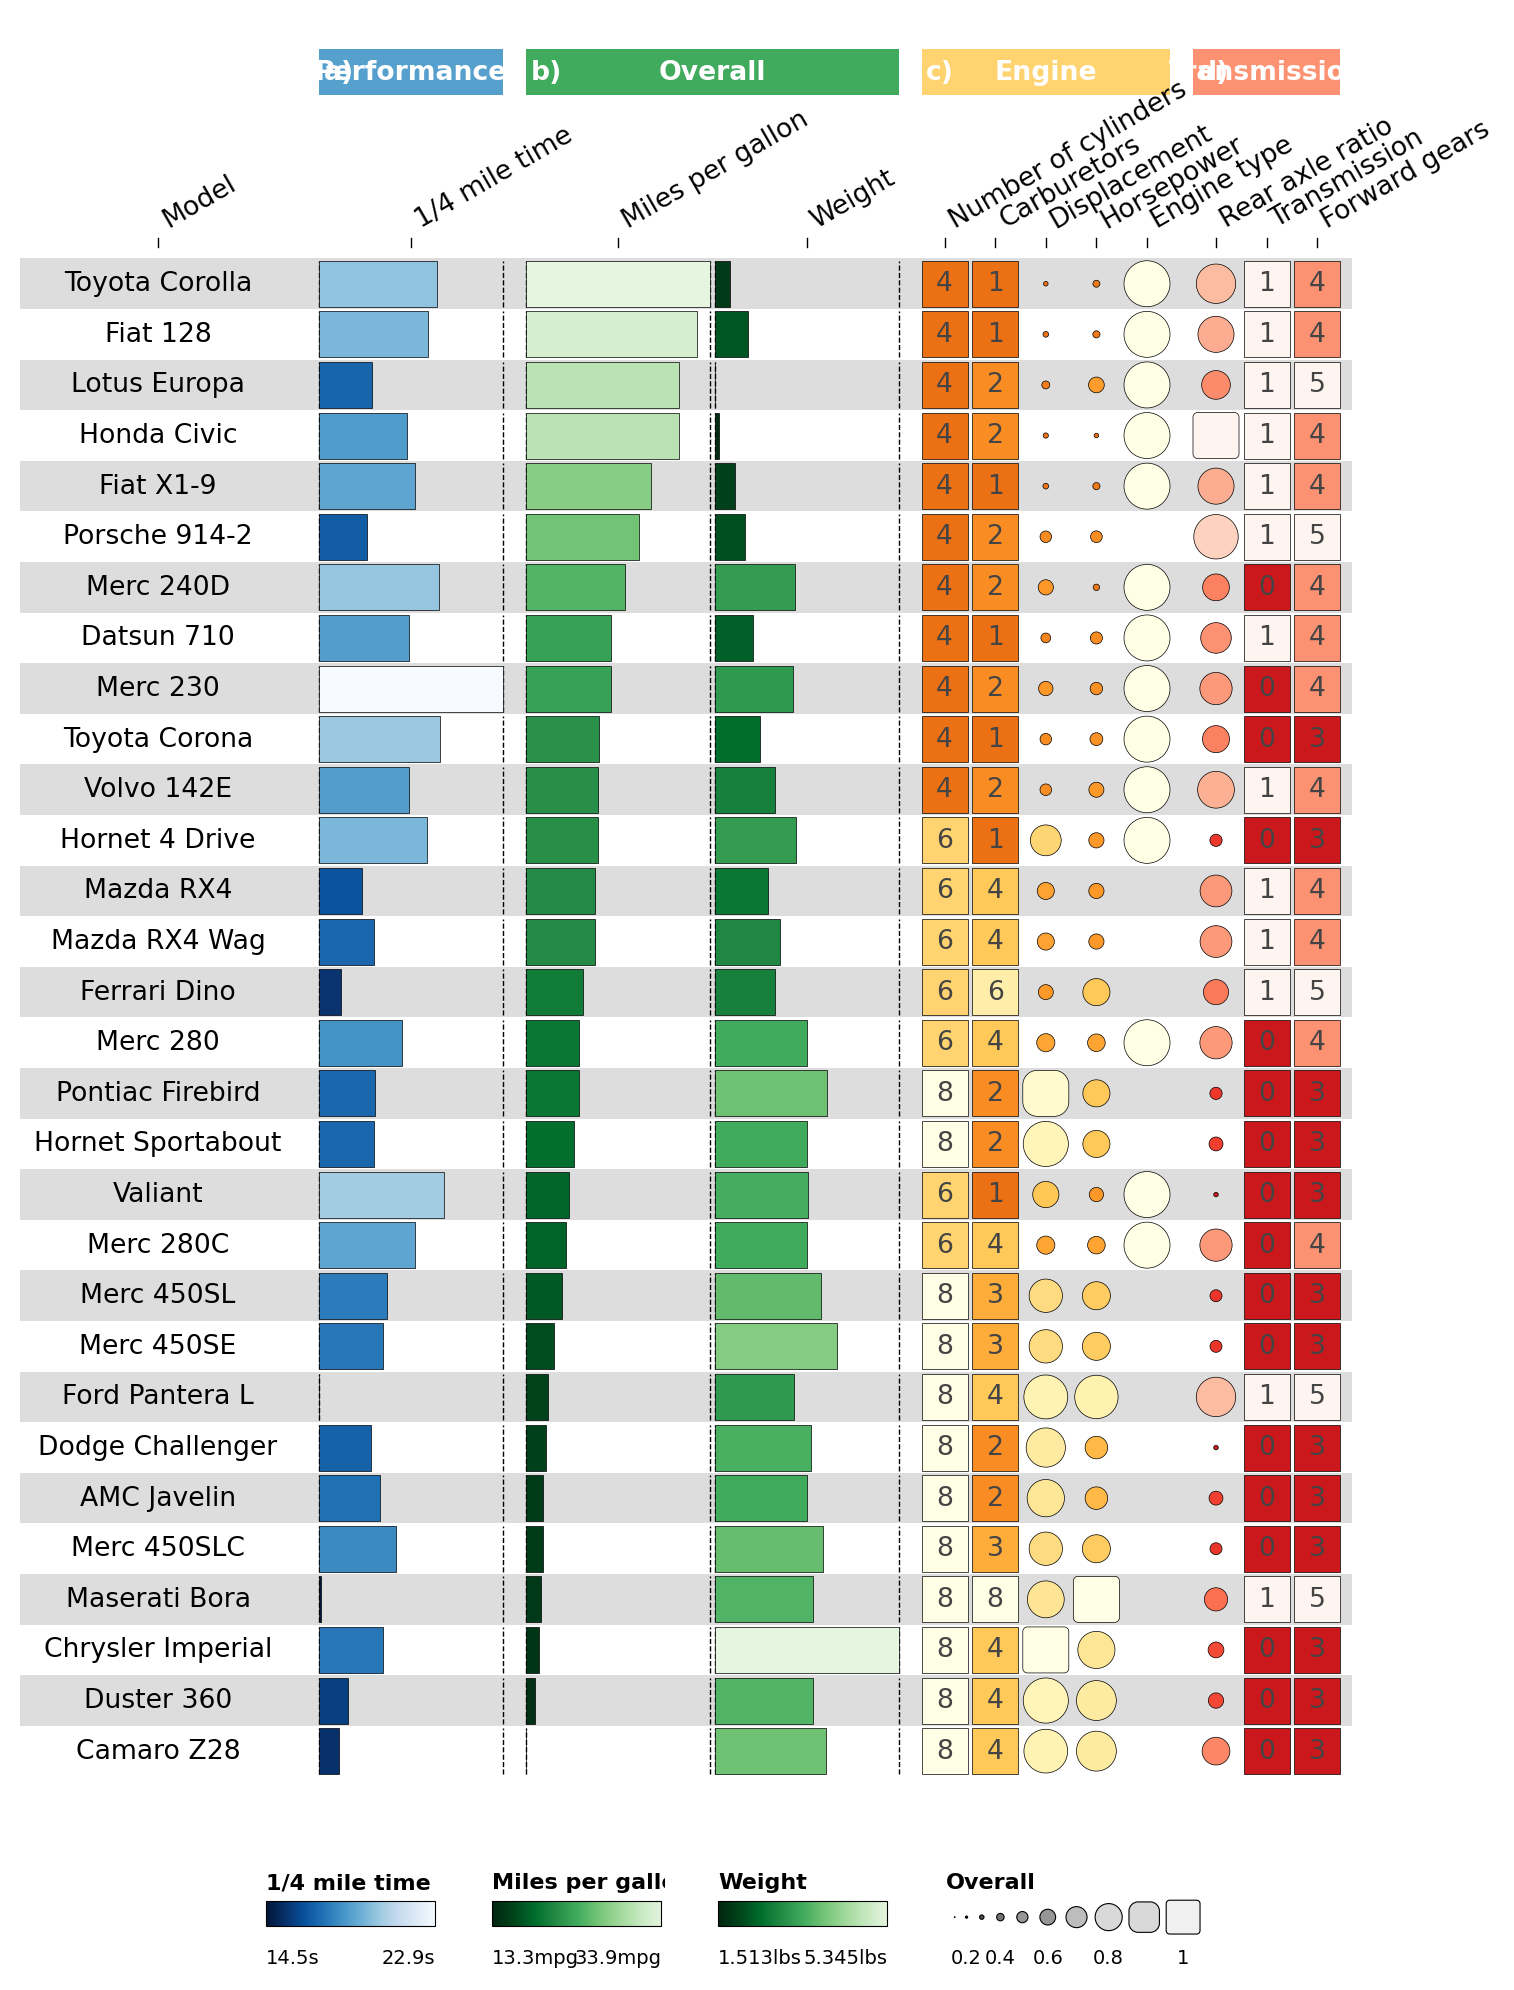

In [19]:
legends = legends + [
    dict(palette='engine_palette',       enabled=False),
    dict(palette='transmission_palette', enabled=False),
]
ov.pl.funky_heatmap(data, column_info=cinfo, column_groups=column_groups,
                    palettes=palettes, legends=legends)

### 2.7 Row grouping

Highlight Mercedes cars by adding `row_info` + `row_groups`.

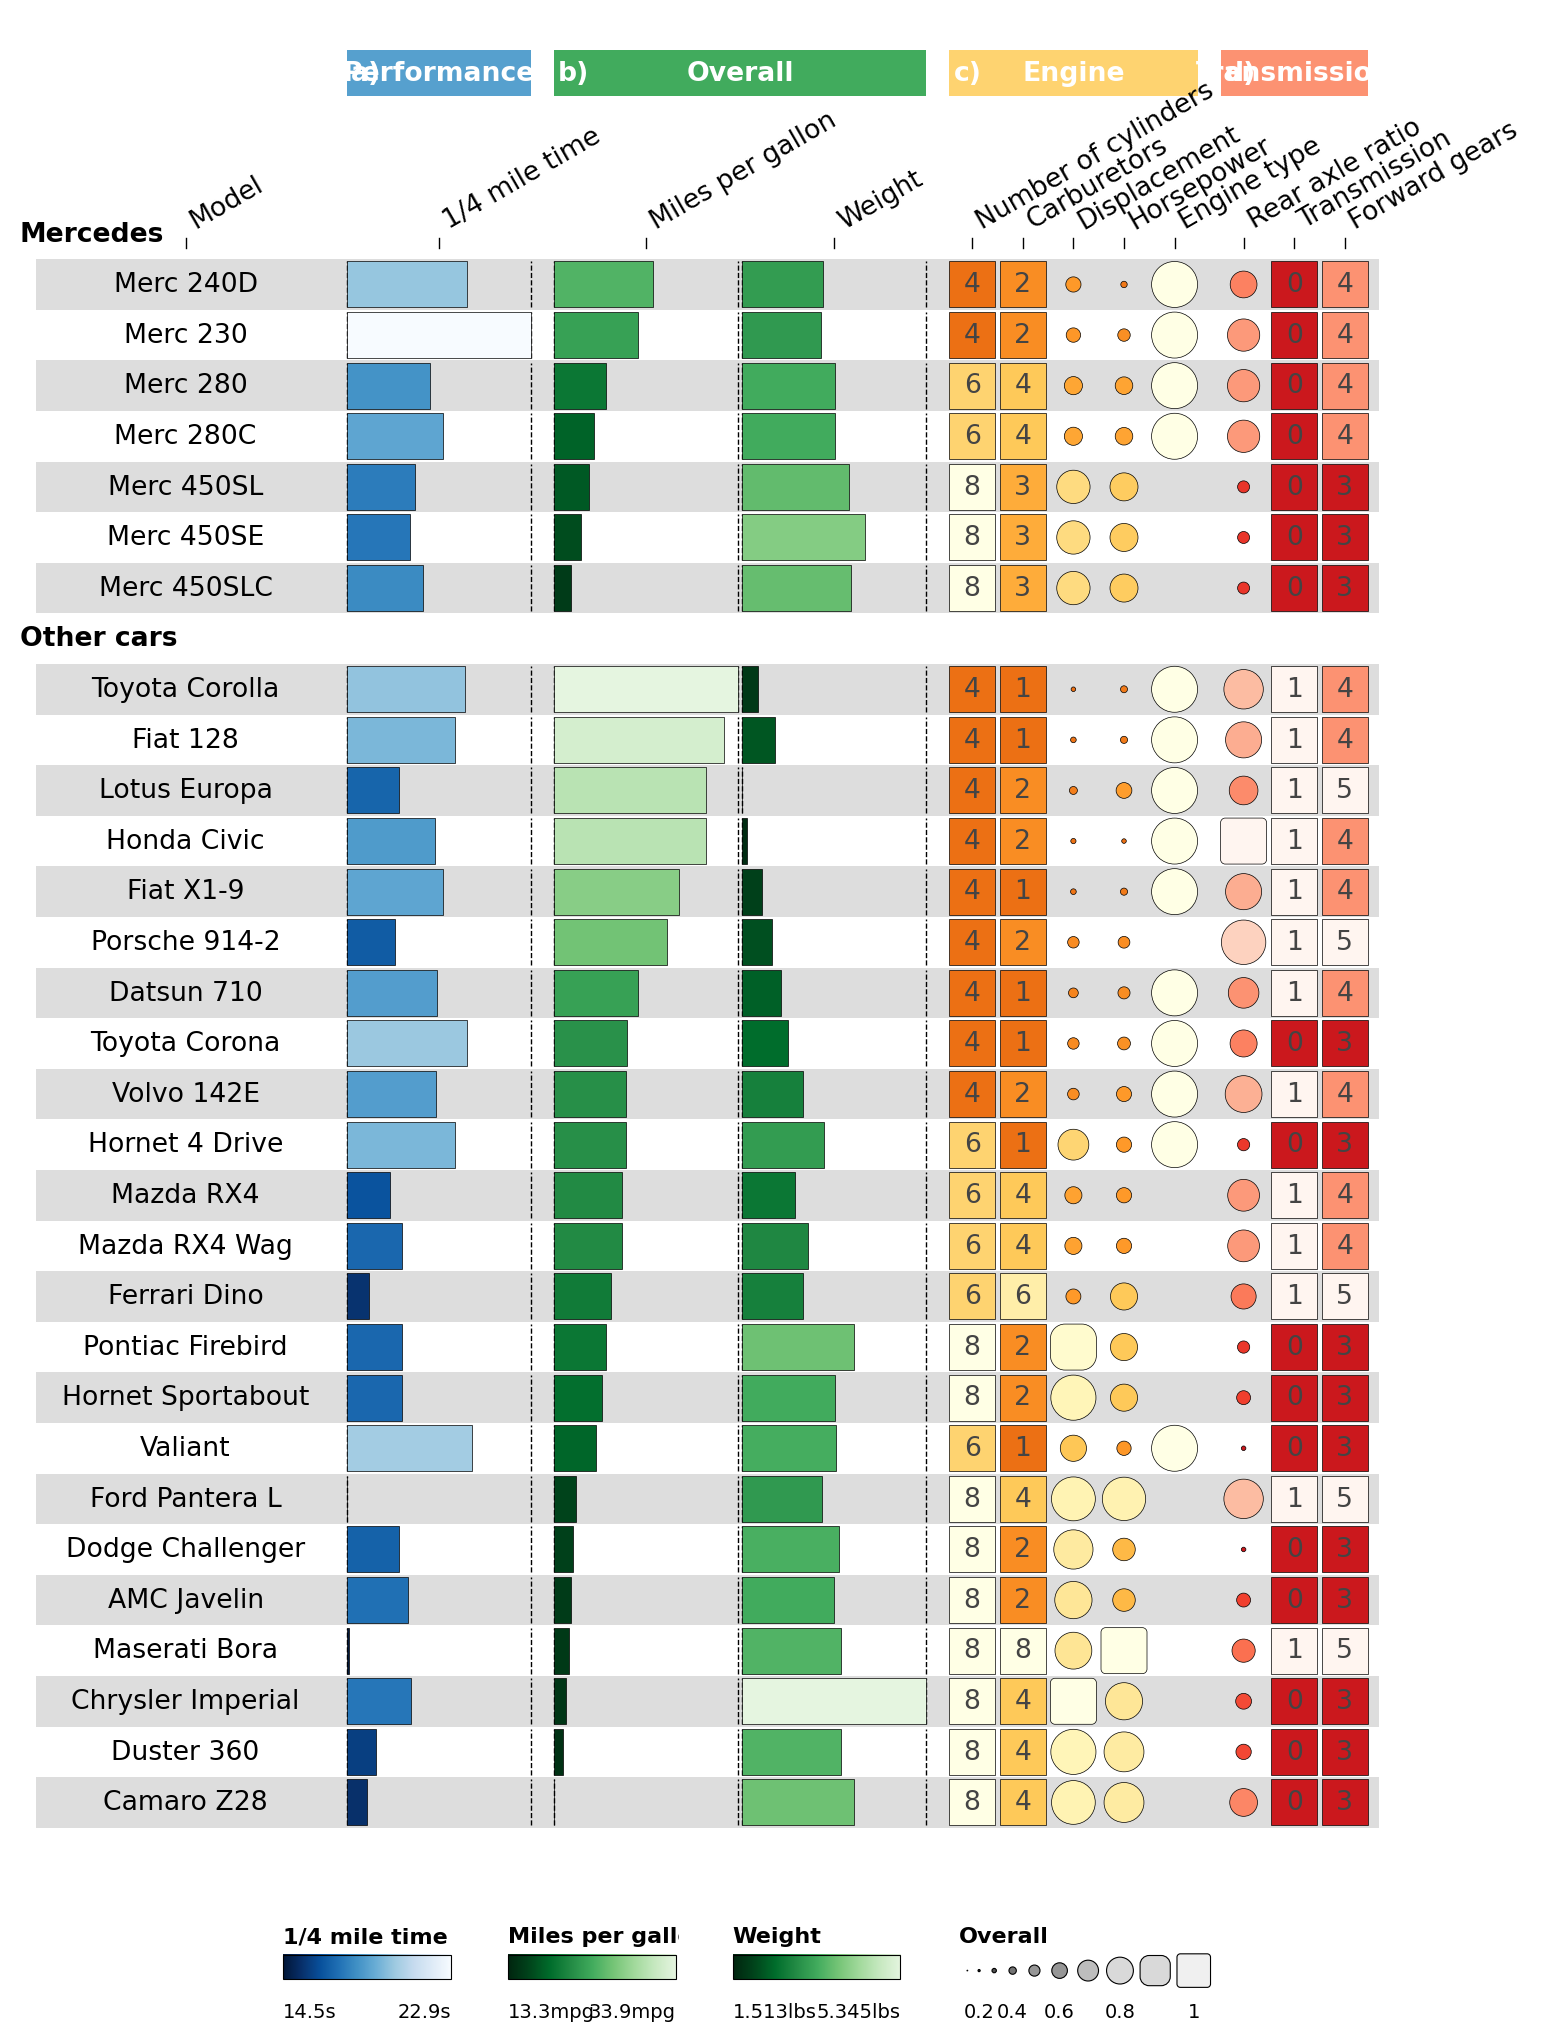

In [20]:
row_info = pd.DataFrame({
    'id':    data['id'].to_numpy(),
    'group': ['Mercedes' if 'Merc' in str(x) else 'Other' for x in data['id']],
})
order = row_info['group'].argsort(kind='mergesort')
data = data.iloc[order].reset_index(drop=True)
row_info = row_info.iloc[order].reset_index(drop=True)

row_groups = pd.DataFrame({
    'level1': ['Mercedes', 'Other cars'],
    'group':  ['Mercedes', 'Other'],
})

ov.pl.funky_heatmap(data, column_info=cinfo, column_groups=column_groups,
                    palettes=palettes, legends=legends,
                    row_info=row_info, row_groups=row_groups)

### 2.8 Final spacing tweaks

Use the per-column `options.width` to nudge the `Transmission` column
group wider.

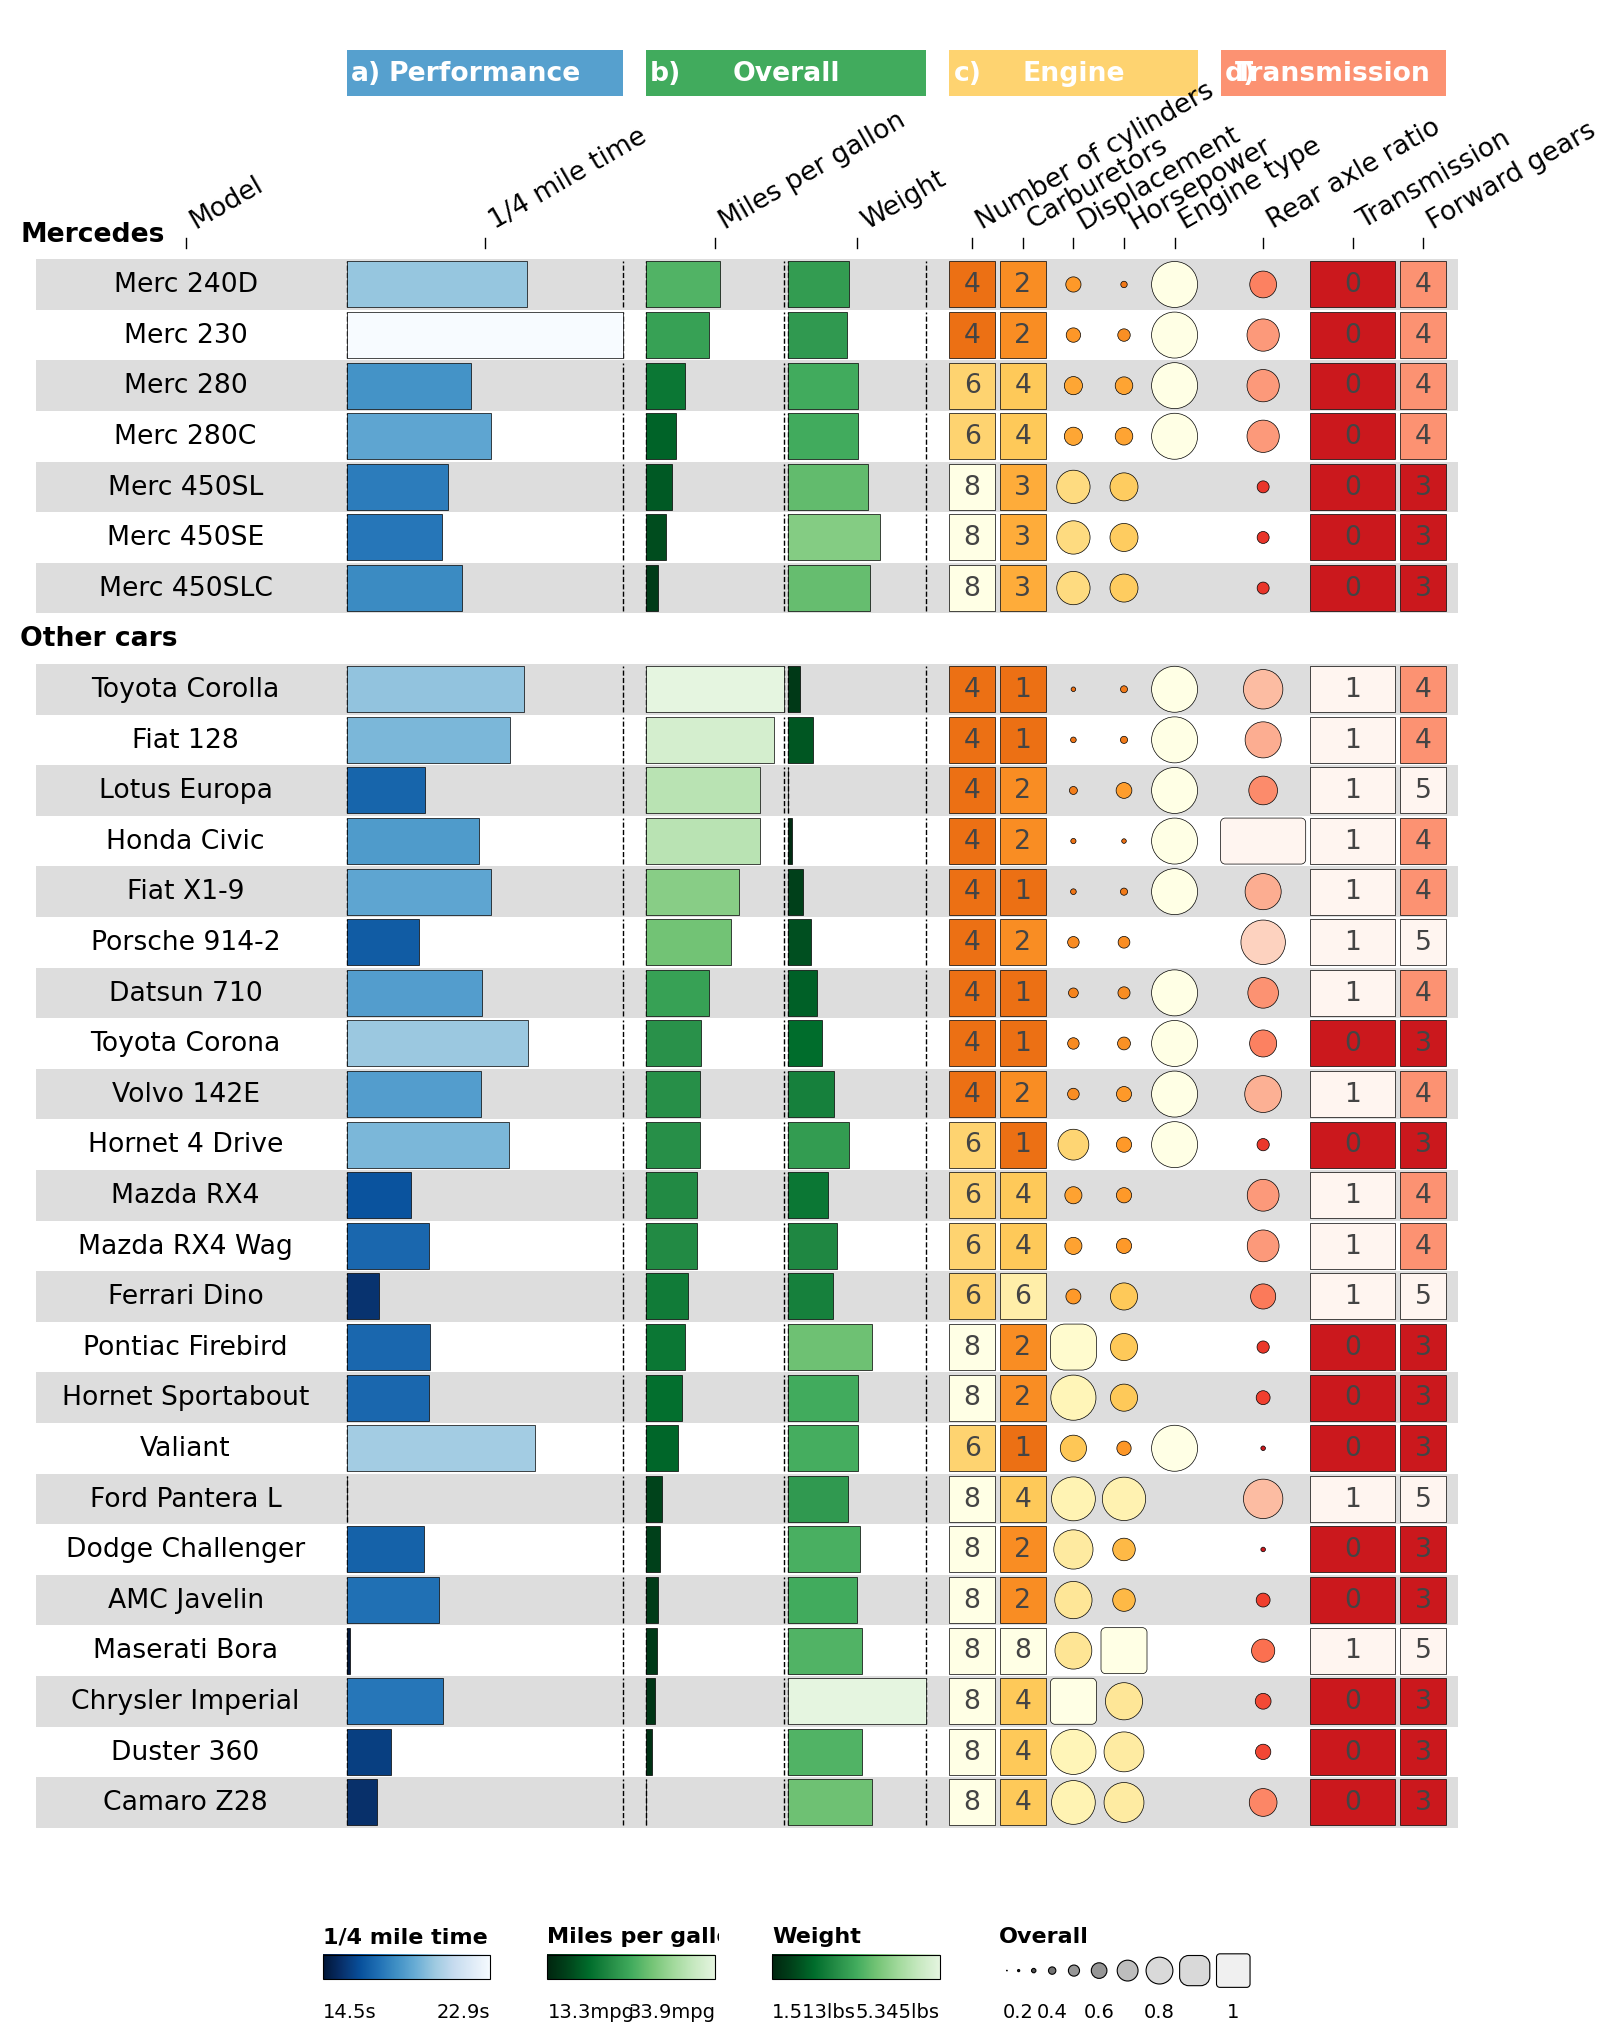

In [21]:
def set_option(df, iloc, **opts):
    o = json.loads(df.iloc[iloc]['options']) if df.iloc[iloc]['options'] else {}
    o.update(opts)
    df.at[iloc, 'options'] = json.dumps(o)
    return df

for i, w in [(0, 6), (1, 6), (2, 3), (3, 3), (11, 1.85), (12, 1.85)]:
    cinfo = set_option(cinfo, i, width=w)

fh = ov.pl.funky_heatmap(data, column_info=cinfo, column_groups=column_groups,
                         palettes=palettes, legends=legends,
                         row_info=row_info, row_groups=row_groups)
fh

## Part 3 · Recreating the scIB figures

Python 1:1 port of the R [scIB](https://funkyheatmap.github.io/funkyheatmap/articles/scIB.html) vignette.

The [scIB project](https://theislab.github.io/scib-reproducibility/)
benchmarked methods for integrating single-cell RNA + ATAC data. We
reproduce the RNA-summary figure using the same fixture table shipped
with `funkyheatmap`.

### 3.1 Data

The figure uses three small icons (matrix / embedding / graph) in its
*Output* column. We download them from the upstream `py-funkyheatmap`
repo so the `image` geom can find them on disk.

In [22]:
from pathlib import Path
Path('images').mkdir(exist_ok=True)
for name in ('matrix', 'embedding', 'graph'):
    dst = Path('images') / f'{name}.png'
    if not dst.exists():
        url = f'https://raw.githubusercontent.com/omicverse/py-funkyheatmap/main/examples/images/{name}.png'
        with urllib.request.urlopen(url) as r, open(dst, 'wb') as f:
            f.write(r.read())
sorted(Path('images').iterdir())

[PosixPath('images/embedding.png'),
 PosixPath('images/graph.png'),
 PosixPath('images/matrix.png')]

In [23]:
csv = urllib.request.urlopen(f'{_RAW}/scib_summary.csv').read().decode()
scib_summary = pd.read_csv(StringIO(csv))
print('shape:', scib_summary.shape)
scib_summary.head().T.head(15)

shape: (20, 27)


,0,1,2,3,4
method,scANVI*,Scanorama,scVI,FastMNN,Harmony
output,Embedding,Embedding,Embedding,Embedding,Embedding
features,HVG,HVG,HVG,HVG,HVG
scaling,Unscaled,Scaled,Unscaled,Unscaled,Unscaled
avg_rank,4.6,8.0,9.4,10.4,13.2
overall_immune_cell_hum,0.821714,0.848437,0.788039,0.845619,0.818014
overall_immune_cell_hum_mou,0.627515,0.641593,0.636712,0.604928,0.538062
overall_lung_atlas,0.755794,0.708848,0.719602,0.708385,0.64694
overall_mouse_brain,0.733199,0.672544,0.677342,0.606238,0.690298
overall_pancreas,0.723885,0.703484,0.713405,0.720063,0.790036


Prepare the table: add `id` from row order, relabel `scaling`/`features`,
attach `output_img` paths per output type, compute top-3 rank labels,
and scale rank columns to [0, 1] of negated rank (better → brighter).

In [24]:
def label_top_3(scores, method='average'):
    s = pd.Series(scores)
    ranks = s.rank(method=method, ascending=True)
    return np.where(
        (ranks <= 3) & ranks.notna(),
        ranks.fillna(-1).round().astype(int).astype(str),
        '',
    )

scib = scib_summary.copy()
scib['id'] = (np.arange(len(scib)) + 1).astype(str)
scib['scaling']  = scib['scaling'].map({'Unscaled':'-', 'Scaled':'+'}).astype(str)
scib['features'] = scib['features'].map({'Full':'FULL', 'HVG':'HVG'}).astype(str)
scib['output_img'] = scib['output'].map({
    'Features':  'images/matrix.png',
    'Embedding': 'images/embedding.png',
    'Graph':     'images/graph.png',
})

for col in ['pancreas','lung_atlas','immune_cell_hum','immune_cell_hum_mou',
            'mouse_brain','simulations_1_1','simulations_2']:
    scib[f'label_{col}'] = label_top_3(scib[f'rank_{col}'])
for col, lab in [('package_rank','package_label'), ('paper_rank','paper_label'),
                 ('time_rank','time_label'),       ('memory_rank','memory_label')]:
    scib[lab] = label_top_3(scib[col], method='min')

for col in ['rank_pancreas','rank_lung_atlas','rank_immune_cell_hum',
            'rank_immune_cell_hum_mou','rank_mouse_brain','rank_simulations_1_1',
            'rank_simulations_2','package_rank','paper_rank','time_rank','memory_rank']:
    scib[col] = ov.pl.funky_scale_minmax(-scib[col])

scib.shape

(20, 40)

### 3.2 Column information

We replicate the R `tribble` row-for-row. Each row declares `id`,
`id_color` (column used for the colour ramp), `name`, `geom`, `group`,
and an `options` JSON dict that spreads into per-column knobs (`hjust`,
`width`, `palette`, `draw_outline`, `overlay`).

In [25]:
def CI(id_, id_color, name, geom, group, **opts_kw):
    return {'id': id_, 'id_color': id_color, 'name': name,
            'geom': geom, 'group': group, 'options': json.dumps(opts_kw)}

column_info = pd.DataFrame([
    CI('id',                          None,                       'Rank',                'text',  'Method',      hjust=0),
    CI('method',                      None,                       'Method',              'text',  'Method',      hjust=0, width=5),
    CI('output_img',                  None,                       'Output',              'image', 'Method'),
    CI('features',                    'features',                 'Features',            'text',  'Method',      palette='features', width=2),
    CI('scaling',                     None,                       'Scaling',             'text',  'Method',      fontface='bold'),
    CI('overall_pancreas',            'rank_pancreas',            'Pancreas',            'bar',   'RNA',         palette='blues',  width=1.5, draw_outline=False),
    CI('label_pancreas',              None,                       None,                  'text',  'RNA',         hjust=0.1, overlay=True),
    CI('overall_lung_atlas',          'rank_lung_atlas',          'Lung',                'bar',   'RNA',         palette='blues',  width=1.5, draw_outline=False),
    CI('label_lung_atlas',            None,                       None,                  'text',  'RNA',         hjust=0.1, overlay=True),
    CI('overall_immune_cell_hum',     'rank_immune_cell_hum',     'Immune (human)',      'bar',   'RNA',         palette='blues',  width=1.5, draw_outline=False),
    CI('label_immune_cell_hum',       None,                       None,                  'text',  'RNA',         hjust=0.1, overlay=True),
    CI('overall_immune_cell_hum_mou', 'rank_immune_cell_hum_mou', 'Immune (human/mouse)','bar',   'RNA',         palette='blues',  width=1.5, draw_outline=False),
    CI('label_immune_cell_hum_mou',   None,                       None,                  'text',  'RNA',         hjust=0.1, overlay=True),
    CI('overall_mouse_brain',         'rank_mouse_brain',         'Mouse brain',         'bar',   'RNA',         palette='blues',  width=1.5, draw_outline=False),
    CI('label_mouse_brain',           None,                       None,                  'text',  'RNA',         hjust=0.1, overlay=True),
    CI('overall_simulations_1_1',     'rank_simulations_1_1',     'Sim 1',               'bar',   'Simulations', palette='greens', width=1.5, draw_outline=False),
    CI('label_simulations_1_1',       None,                       None,                  'text',  'Simulations', hjust=0.1, overlay=True),
    CI('overall_simulations_2',       'rank_simulations_2',       'Sim 2',               'bar',   'Simulations', palette='greens', width=1.5, draw_outline=False),
    CI('label_simulations_2',         None,                       None,                  'text',  'Simulations', hjust=0.1, overlay=True),
    CI('package_score',               'package_rank',             'Package',             'bar',   'Usability',   palette='oranges', width=1.5, draw_outline=False),
    CI('package_label',               None,                       None,                  'text',  'Usability',   hjust=0.1, overlay=True),
    CI('paper_score',                 'paper_rank',               'Paper',               'bar',   'Usability',   palette='oranges', width=1.5, draw_outline=False),
    CI('paper_label',                 None,                       None,                  'text',  'Usability',   hjust=0.1, overlay=True),
    CI('time_score',                  'time_rank',                'Time',                'bar',   'Scalability', palette='greys',   width=1.5, draw_outline=False),
    CI('time_label',                  None,                       None,                  'text',  'Scalability', hjust=0.1, overlay=True),
    CI('memory_score',                'memory_rank',              'Memory',              'bar',   'Scalability', palette='greys',   width=1.5, draw_outline=False),
    CI('memory_label',                None,                       None,                  'text',  'Scalability', hjust=0.1, overlay=True),
])
column_info.head()

,id,id_color,name,geom,group,options
0,id,None,Rank,text,Method,"{""hjust"": 0}"
1,method,None,Method,text,Method,"{""hjust"": 0, ""width"": 5}"
2,output_img,None,Output,image,Method,{}
3,features,features,Features,text,Method,"{""palette"": ""features"", ""width"": 2}"
4,scaling,None,Scaling,text,Method,"{""fontface"": ""bold""}"


### 3.3 Column groups, row info, palettes, legends

In [26]:
column_groups = pd.DataFrame({
    'group':   ['Method', 'RNA', 'Simulations', 'Usability', 'Scalability'],
    'palette': ['black',  'blues','greens',     'oranges',   'greys'],
    'level1':  ['Method', 'RNA', 'Simulations', 'Usability', 'Scalability'],
})

row_info = pd.DataFrame({'id': scib['id'].astype(str),
                         'group': [None] * len(scib)})

oranges = list(reversed([
    '#FFF5EB','#FEE6CE','#FDD0A2','#FDAE6B','#FD8D3C',
    '#F16913','#D94801','#A63603','#7F2704'
]))
palettes = {
    'features': {'FULL': '#4c4c4c', 'HVG': '#006300'},
    'blues': 'Blues',
    'greens': 'Greens',
    'oranges': oranges,
    'greys': 'Greys',
    'black': ['black','black'],
}

legends = [
    dict(title='Scaling',         geom='text', values=['Scaled','Unscaled'], labels=['+','-'], label_width=.5),
    dict(title='RNA rank',         palette='blues',   geom='rect', labels=['20',' ','10',' ','1'], size=[1,1,1,1,1]),
    dict(title='Simulations rank', palette='greens',  geom='rect', labels=['20',' ','10',' ','1'], size=[1,1,1,1,1]),
    dict(title='Usability rank',   palette='oranges', geom='rect', labels=['20',' ','10',' ','1'], size=[1,1,1,1,1]),
    dict(title='Scalability rank', palette='greys',   geom='rect', labels=['20',' ','10',' ','1'], size=[1,1,1,1,1]),
]

### 3.4 Render the figure

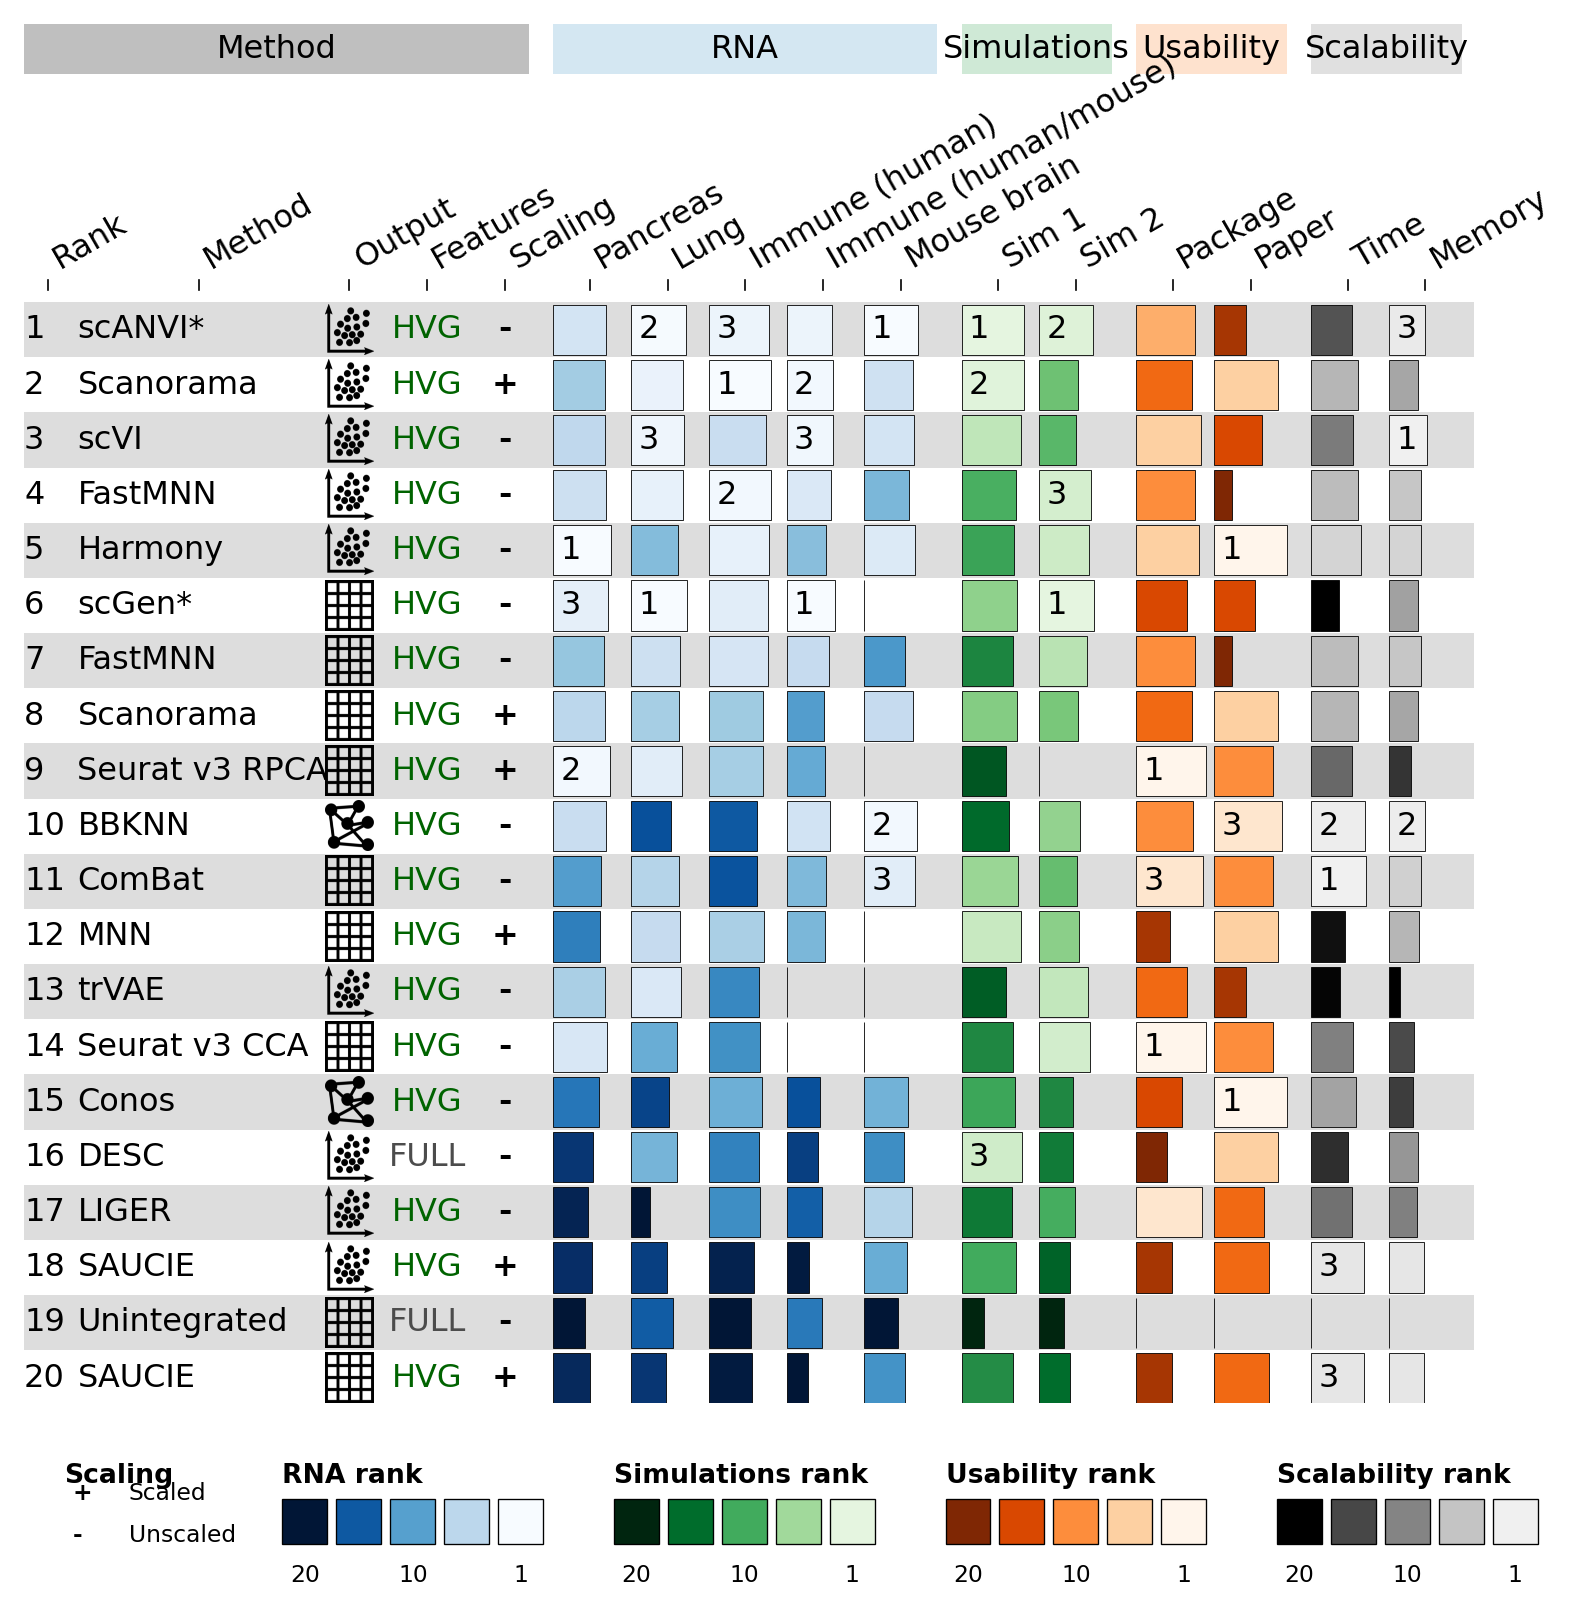

In [27]:
fh = ov.pl.funky_heatmap(
    data=scib,
    column_info=column_info,
    column_groups=column_groups,
    row_info=row_info,
    palettes=palettes,
    legends=legends,
    position_args=ov.pl.funky_position_arguments(col_annot_offset=4),
    scale_column=False,
    fig_scale=0.22,
    dpi=120,
)
fh

The figure shows the same 20 methods, the same RNA / Simulations /
Usability / Scalability column groups, top-3 rank labels overlaid on
each bar, and a five-panel legend strip at the bottom (Scaling
text legend + four rank gradient legends).

## Part 4 · dynbenchmark

The full dynbenchmark figure — 51 trajectory-inference methods × 159
columns — would be too long to include inline. See the upstream
[`examples/dynbenchmark.ipynb`](https://github.com/omicverse/py-funkyheatmap/blob/main/examples/dynbenchmark.ipynb)
for the complete reproduction with row groups (Graph / Tree / Multi /
Bi / Linear / Cyclic methods) and the six-palette legend strip.

A miniature version is included as Quick start §1.6.

## References

- Saelens, W., Cannoodt, R., Todorov, H. *et al.*
  **A comparison of single-cell trajectory inference methods.**
  *Nat Biotechnol* 37, 547–554 (2019).
- Luecken, M.D., Büttner, M., Chaichoompu, K. *et al.*
  **Benchmarking atlas-level data integration in single-cell genomics.**
  *Nat Methods* 19, 41–50 (2022).
- [`py-funkyheatmap` on GitHub](https://github.com/omicverse/py-funkyheatmap)
- [`funkyheatmap` (R)](https://funkyheatmap.github.io/funkyheatmap/)